# Entregable 1 · Data Preparation · BMW Pricing

**Máster en Data Science & AI**  
**Objetivo:** preparar un dataset limpio y preprocesado, listo para una fase posterior de modelado para predecir el precio de vehículos BMW a partir de sus características.

## Organización para trabajo colaborativo en GitHub

Este notebook está preparado para que **cada integrante trabaje el flujo completo en su propio apartado**, sin pisar el trabajo del resto.

Cada persona tiene las mismas secciones:

1. Auditoría inicial del dataset.
2. Limpieza de datos.
3. Feature engineering.
4. Preprocessing para modelado posterior.
5. Validaciones finales y exportación.
6. Conclusiones.

> Recomendación para GitHub: cada integrante puede trabajar en su propia rama o modificar únicamente su bloque. Luego el equipo compara enfoques y consolida una versión final.

## Checklist del entregable

- Cargar y revisar el dataset original.
- Analizar tipos de datos, nulos, duplicados y consistencia general.
- Aplicar limpieza de datos justificando cada decisión.
- Tratar valores faltantes con criterios reproducibles.
- Analizar y tratar outliers cuando corresponda.
- Preparar variables para una futura fase de modelado.
- Exportar un dataset final limpio y preparado.

**Importante:** en este entregable no se entrena ningún modelo predictivo. El objetivo termina en dejar el dataset listo para modelado.

## Integrantes

- Adria Viñas
- Carmen Candial
- Juan Ceruso
- Maximiliano Cifuentes


## 0. Setup común del proyecto

Esta sección es común a todo el equipo. Idealmente no debería modificarse salvo que el equipo acuerde un cambio general.


In [1]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Configuración general
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "bmw_pricing.csv"


In [2]:
def pretty_table(df, precision=2):
    """Devuelve una tabla estilizada para mejorar la lectura en el notebook."""
    return (
        df.style
        .format(precision=precision, thousands=",")
        .set_properties(**{
            "text-align": "center",
            "padding": "8px",
            "border": "1px solid #dbeafe"
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#0b1f3a"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #dbeafe")
            ]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#e0f2fe")]},
            {"selector": "tbody tr:nth-child(odd)", "props": [("background-color", "#ffffff")]}
        ])
    )


def resumen_calidad(df):
    """Resumen de calidad por columna: tipo, nulos, porcentaje de nulos y cardinalidad."""
    resumen = pd.DataFrame({
        "columna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "nulos": df.isna().sum().values,
        "porcentaje_nulos": (df.isna().mean() * 100).round(2).values,
        "valores_unicos": df.nunique(dropna=True).values
    })
    return resumen.sort_values(["porcentaje_nulos", "valores_unicos"], ascending=[False, False])


def plot_distribution(df, column, title=None):
    """Histograma y boxplot simple para revisar distribución y posibles outliers."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(df[column].dropna(), bins=30, kde=True, ax=axes[0], color="#0b1f3a")
    axes[0].set_title(title or f"Distribución de {column}")
    sns.boxplot(x=df[column], ax=axes[1], color="#e0f2fe")
    axes[1].set_title(f"Boxplot de {column}")
    plt.tight_layout()
    plt.show()


In [3]:
# Carga única del dataset original
# Cada integrante debe partir de df_raw.copy() dentro de su propio bloque.
df_raw = pd.read_csv(DATA_PATH)

print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")
pretty_table(df_raw.head())


Filas: 4,843
Columnas: 18


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,nan,118,"140,411.00",100.00,2012-02-01,diesel,black,nan,True,True,False,nan,True,nan,True,nan,"11,300.00",2018-01-01
1,BMW,M4,"13,929.00",317.00,nan,petrol,grey,convertible,True,True,False,nan,False,True,True,True,"69,700.00",2018-02-01
2,BMW,320,"183,297.00",120.00,2012-04-01,diesel,white,nan,False,False,False,nan,True,False,True,False,"10,200.00",2018-02-01
3,BMW,420,"128,035.00",135.00,nan,diesel,red,convertible,True,True,False,nan,True,True,True,nan,"25,100.00",2018-02-01
4,BMW,425,"97,097.00",160.00,nan,diesel,silver,nan,True,True,False,False,False,True,True,True,"33,400.00",2018-04-01


In [4]:
# Diccionario base de variables
# Se puede copiar o ajustar dentro de cada bloque si se proponen cambios.
data_dictionary_base = pd.DataFrame({
    "variable": df_raw.columns,
    "descripcion": [
        "Marca del vehículo",
        "Modelo del vehículo",
        "Kilometraje acumulado",
        "Potencia del vehículo",
        "Fecha de registro o matriculación",
        "Tipo de combustible",
        "Color del vehículo",
        "Tipo de carrocería",
        "Indica si el volante es regulable",
        "Indica si tiene aire acondicionado",
        "Indica si tiene cámara trasera",
        "Indica si tiene asientos traseros plegables",
        "Indica si tiene elevalunas eléctrico",
        "Indica si tiene bluetooth",
        "Indica si tiene GPS",
        "Indica si tiene alerta de límite de velocidad",
        "Precio de venta. Variable objetivo",
        "Fecha de venta"
    ],
    "tipo_esperado": [
        "categórica", "categórica", "numérica", "numérica", "fecha", "categórica", "categórica",
        "categórica", "booleana", "booleana", "booleana", "booleana", "booleana", "booleana",
        "booleana", "booleana", "numérica target", "fecha"
    ]
})

pretty_table(data_dictionary_base)


,variable,descripcion,tipo_esperado
0,marca,Marca del vehículo,categórica
1,modelo,Modelo del vehículo,categórica
2,km,Kilometraje acumulado,numérica
3,potencia,Potencia del vehículo,numérica
4,fecha_registro,Fecha de registro o matriculación,fecha
5,tipo_gasolina,Tipo de combustible,categórica
6,color,Color del vehículo,categórica
7,tipo_coche,Tipo de carrocería,categórica
8,volante_regulable,Indica si el volante es regulable,booleana
9,aire_acondicionado,Indica si tiene aire acondicionado,booleana


# Workspace · Juan

Este apartado replica el flujo completo de Data Preparation para que **Juan** pueda trabajar de punta a punta sin modificar el bloque de otra persona.

Convención de variables de este bloque: todas terminan en `_juan` para evitar conflictos al ejecutar el notebook completo.


## Juan · 1. Auditoría inicial del dataset

Objetivo: documentar la estructura inicial del dataset y detectar problemas antes de limpiar.

Preguntas a responder:

- ¿Cuántas filas y columnas hay?
- ¿Qué tipo de dato tiene cada variable?
- ¿Qué columnas tienen valores faltantes?
- ¿Existen duplicados?
- ¿La variable objetivo `precio` está disponible y es válida?


In [5]:
# Copia de trabajo de Juan
df_juan = df_raw.copy()

print("Dimensión inicial:", df_juan.shape)
df_juan.info()


Dimensión inicial: (4843, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   o

In [6]:
# Resumen de nulos, tipos y cardinalidad
quality_initial_juan = resumen_calidad(df_juan)
pretty_table(quality_initial_juan)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,object,"3,391",70.02,2
4,fecha_registro,object,"2,423",50.03,180
7,tipo_coche,object,"1,460",30.15,8
0,marca,object,970,20.03,1
13,bluetooth,object,728,15.03,2
15,alerta_lim_velocidad,object,728,15.03,2
9,aire_acondicionado,object,486,10.04,2
6,color,object,445,9.19,10
16,precio,float64,6,0.12,437
5,tipo_gasolina,object,5,0.10,5


In [7]:
# Duplicados exactos
duplicados_juan = df_juan.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados_juan}")

if duplicados_juan > 0:
    display(pretty_table(df_juan[df_juan.duplicated()].head(10)))


Filas duplicadas exactas: 0


In [8]:
# Revisión de la variable objetivo
pretty_table(df_juan[["precio"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
precio,"4,837.00","15,831.92","9,222.63",100.00,"10,800.00","14,200.00","18,600.00","178,500.00"


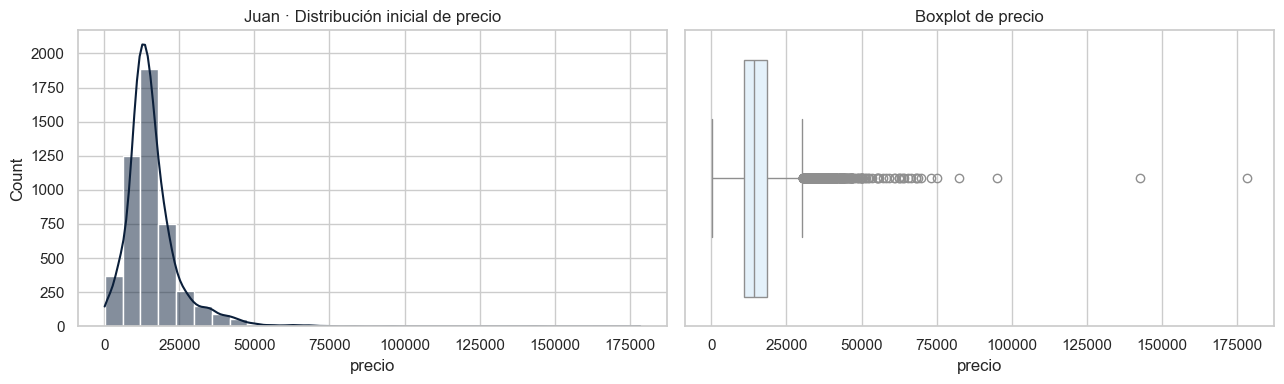

In [9]:
plot_distribution(df_juan, "precio", "Juan · Distribución inicial de precio")


### Juan · 1.1 Diccionario de variables

Completar o ajustar si se detectan interpretaciones distintas de las variables.


In [10]:
data_dictionary_juan = data_dictionary_base.copy()
pretty_table(data_dictionary_juan)


,variable,descripcion,tipo_esperado
0,marca,Marca del vehículo,categórica
1,modelo,Modelo del vehículo,categórica
2,km,Kilometraje acumulado,numérica
3,potencia,Potencia del vehículo,numérica
4,fecha_registro,Fecha de registro o matriculación,fecha
5,tipo_gasolina,Tipo de combustible,categórica
6,color,Color del vehículo,categórica
7,tipo_coche,Tipo de carrocería,categórica
8,volante_regulable,Indica si el volante es regulable,booleana
9,aire_acondicionado,Indica si tiene aire acondicionado,booleana


## Juan · 2. Limpieza de datos

Objetivo: aplicar reglas claras de limpieza, dejando un dataset coherente antes del preprocessing.

Decisiones sugeridas a revisar:

1. Eliminar filas sin `precio`, porque es la variable objetivo del futuro modelo.
2. Eliminar duplicados exactos si existieran.
3. Convertir fechas a tipo datetime.
4. Normalizar columnas booleanas que vienen mezcladas como texto/bool/nulos.
5. Revisar columnas con demasiados nulos y decidir si imputar o eliminar.


In [11]:
# Copia para limpieza
clean_juan = df_juan.copy()

# 1) Eliminar registros sin target
rows_before_juan = clean_juan.shape[0]
clean_juan = clean_juan.dropna(subset=["precio"])
print(f"Filas eliminadas por precio nulo: {rows_before_juan - clean_juan.shape[0]}")

# 2) Eliminar duplicados exactos
rows_before_juan = clean_juan.shape[0]
clean_juan = clean_juan.drop_duplicates()
print(f"Filas duplicadas eliminadas: {rows_before_juan - clean_juan.shape[0]}")


Filas eliminadas por precio nulo: 6
Filas duplicadas eliminadas: 0


In [12]:
# 3) Conversión de fechas
for col in ["fecha_registro", "fecha_venta"]:
    clean_juan[col] = pd.to_datetime(clean_juan[col], errors="coerce")

pretty_table(clean_juan[["fecha_registro", "fecha_venta"]].head())


,fecha_registro,fecha_venta
0,2012-02-01 00:00:00,2018-01-01 00:00:00
1,NaT,2018-02-01 00:00:00
2,2012-04-01 00:00:00,2018-02-01 00:00:00
3,NaT,2018-02-01 00:00:00
4,NaT,2018-04-01 00:00:00


In [13]:
# 4) Normalización de variables booleanas
boolean_cols_juan = [
    "volante_regulable",
    "aire_acondicionado",
    "camara_trasera",
    "asientos_traseros_plegables",
    "elevalunas_electrico",
    "bluetooth",
    "gps",
    "alerta_lim_velocidad"
]

def to_boolean_juan(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return value
    value_str = str(value).strip().lower()
    if value_str in ["true", "1", "yes", "y", "si", "sí"]:
        return True
    if value_str in ["false", "0", "no", "n"]:
        return False
    return np.nan

for col in boolean_cols_juan:
    clean_juan[col] = clean_juan[col].apply(to_boolean_juan).astype("boolean")

pretty_table(clean_juan[boolean_cols_juan].head())


,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad
0,True,True,False,,True,,True,
1,True,True,False,,False,True,True,True
2,False,False,False,,True,False,True,False
3,True,True,False,,True,True,True,
4,True,True,False,False,False,True,True,True


### Juan · 2.1 Tratamiento de columnas con alto porcentaje de nulos

Registrar acá el criterio elegido por Juan.

Criterio sugerido:

- Si una columna aporta poca información o tiene un porcentaje de nulos muy elevado, evaluar su eliminación.
- Si la columna puede tener valor predictivo, conservarla e imputarla.


In [14]:
# Estado luego de limpieza básica
quality_after_basic_cleaning_juan = resumen_calidad(clean_juan)
pretty_table(quality_after_basic_cleaning_juan)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,boolean,"3,388",70.04,2
4,fecha_registro,datetime64[ns],"2,418",49.99,180
7,tipo_coche,object,"1,458",30.14,8
0,marca,object,970,20.05,1
13,bluetooth,boolean,728,15.05,2
15,alerta_lim_velocidad,boolean,728,15.05,2
9,aire_acondicionado,boolean,485,10.03,2
6,color,object,444,9.18,10
5,tipo_gasolina,object,5,0.10,5
8,volante_regulable,boolean,4,0.08,2


In [15]:
# Revisión de marca
if "marca" in clean_juan.columns:
    display(pretty_table(clean_juan["marca"].value_counts(dropna=False).rename_axis("marca").reset_index(name="cantidad")))

# Decisión sugerida: eliminar marca porque el caso de estudio se centra en BMW
# Juan puede comentar esta línea si prefiere conservarla y justificarlo.
if "marca" in clean_juan.columns:
    clean_juan = clean_juan.drop(columns=["marca"])

print("Columnas después del tratamiento de marca:")
print(clean_juan.columns.tolist())


,marca,cantidad
0,BMW,"3,867"
1,nan,970


Columnas después del tratamiento de marca:
['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta']


### Juan · 2.2 Imputación de valores faltantes

Registrar acá las decisiones de imputación.

Criterio sugerido:

- Numéricas: mediana.
- Categóricas: `desconocido`.
- Booleanas: `False` como supuesto de característica no informada/no presente.
- Fechas: crear variables temporales y luego imputar las variables derivadas.


In [16]:
# Imputación de categóricas simples
categorical_cols_juan = ["modelo", "tipo_gasolina", "color", "tipo_coche"]
for col in categorical_cols_juan:
    if col in clean_juan.columns:
        clean_juan[col] = clean_juan[col].fillna("desconocido").astype(str).str.strip().str.lower()

# Imputación de booleanas
for col in boolean_cols_juan:
    if col in clean_juan.columns:
        clean_juan[col] = clean_juan[col].fillna(False).astype(bool)

# Imputación de numéricas base
numeric_base_cols_juan = ["km", "potencia"]
for col in numeric_base_cols_juan:
    clean_juan[col] = clean_juan[col].fillna(clean_juan[col].median())

pretty_table(resumen_calidad(clean_juan))


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
3,fecha_registro,datetime64[ns],"2,418",49.99,180
16,fecha_venta,datetime64[ns],1,0.02,13
1,km,float64,0,0.00,"4,778"
15,precio,float64,0,0.00,437
0,modelo,object,0,0.00,77
2,potencia,float64,0,0.00,61
5,color,object,0,0.00,11
6,tipo_coche,object,0,0.00,9
4,tipo_gasolina,object,0,0.00,5
7,volante_regulable,bool,0,0.00,2


### Juan · 2.3 Tratamiento de outliers

Para este entregable, el tratamiento debe ser conservador porque todavía no se modela.

Propuesta base: winsorización por IQR en `precio`, `km` y `potencia`.


In [17]:
def winsorize_iqr_juan(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower=lower, upper=upper), lower, upper

outlier_limits_juan = []
for col in ["precio", "km", "potencia"]:
    clean_juan[col], lower, upper = winsorize_iqr_juan(clean_juan[col])
    outlier_limits_juan.append({"variable": col, "limite_inferior": lower, "limite_superior": upper})

outlier_limits_juan = pd.DataFrame(outlier_limits_juan)
pretty_table(outlier_limits_juan)


,variable,limite_inferior,limite_superior
0,precio,-900.00,"30,300.00"
1,km,"-5,642.50","283,761.50"
2,potencia,47.50,187.50


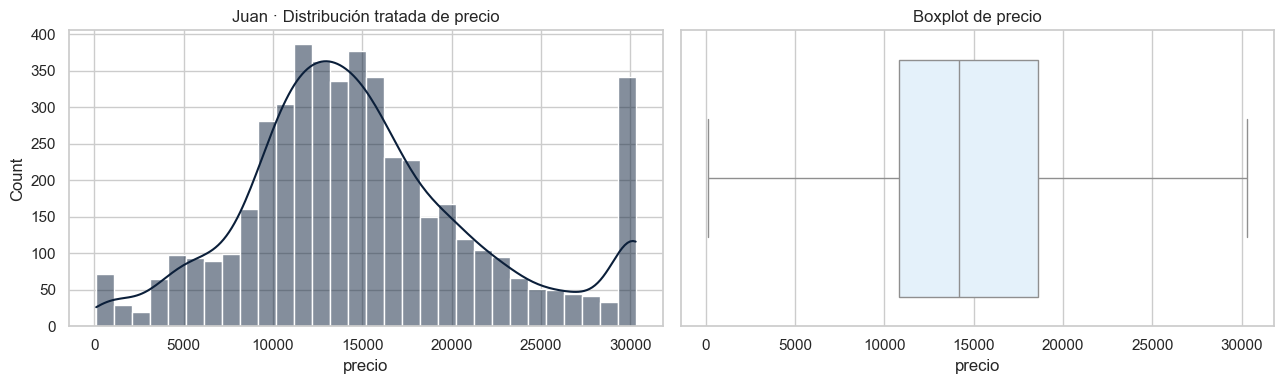

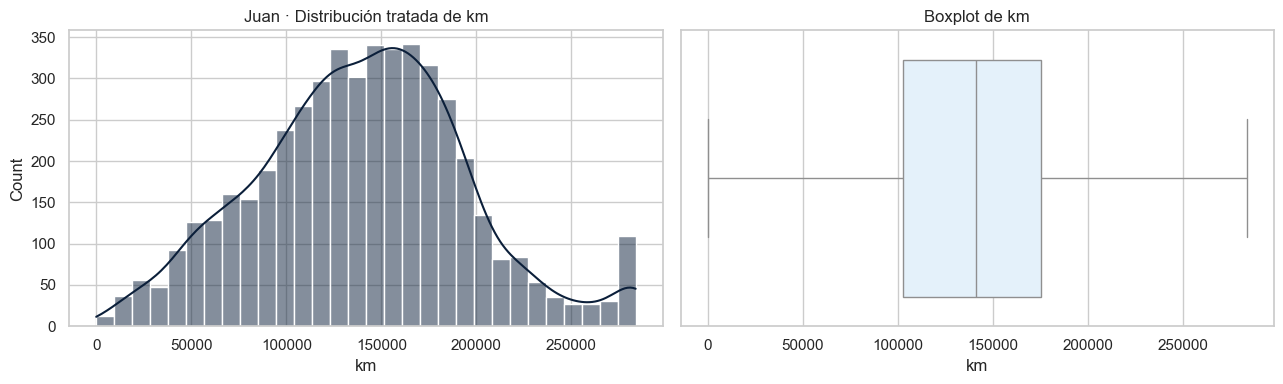

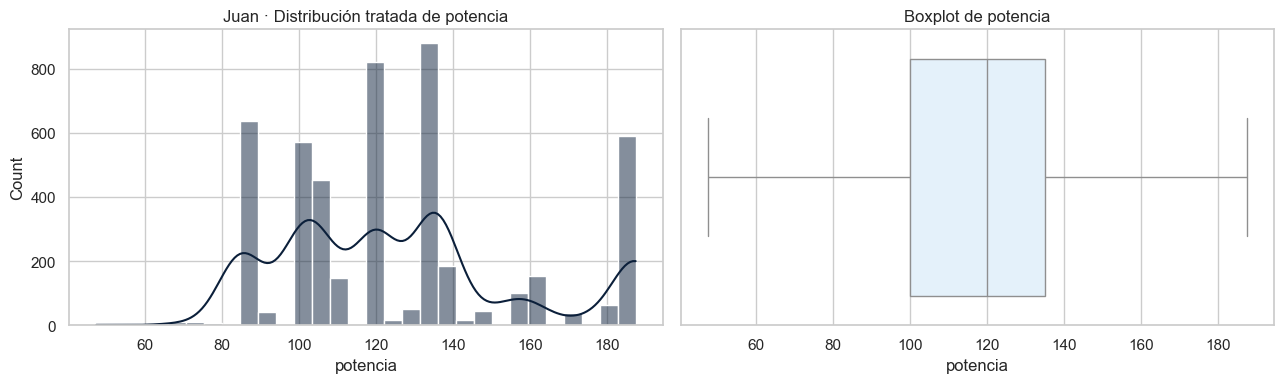

In [18]:
for col in ["precio", "km", "potencia"]:
    plot_distribution(clean_juan, col, f"Juan · Distribución tratada de {col}")


## Juan · 3. Feature engineering

Objetivo: crear variables útiles para modelado sin entrenar ningún modelo.

Variables derivadas propuestas:

- `antiguedad_meses`: diferencia entre fecha de venta y fecha de registro.
- `anio_registro` y `mes_registro`.
- `anio_venta` y `mes_venta`.
- `precio_log`: transformación logarítmica de la variable objetivo para análisis futuro.
- `n_equipamiento`: cantidad de características booleanas presentes.


In [19]:
features_juan = clean_juan.copy()

# Variables temporales
features_juan["anio_registro"] = features_juan["fecha_registro"].dt.year
features_juan["mes_registro"] = features_juan["fecha_registro"].dt.month
features_juan["anio_venta"] = features_juan["fecha_venta"].dt.year
features_juan["mes_venta"] = features_juan["fecha_venta"].dt.month

# Antigüedad en meses
features_juan["antiguedad_meses"] = (
    (features_juan["fecha_venta"].dt.year - features_juan["fecha_registro"].dt.year) * 12 +
    (features_juan["fecha_venta"].dt.month - features_juan["fecha_registro"].dt.month)
)

# Si por nulos o errores queda antigüedad negativa, se reemplaza por NaN antes de imputar
features_juan.loc[features_juan["antiguedad_meses"] < 0, "antiguedad_meses"] = np.nan

# Imputación de variables temporales derivadas
for col in ["anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses"]:
    features_juan[col] = features_juan[col].fillna(features_juan[col].median())

# Transformación de target para análisis futuro
features_juan["precio_log"] = np.log1p(features_juan["precio"])

# Conteo de equipamiento
features_juan["n_equipamiento"] = features_juan[boolean_cols_juan].sum(axis=1)

pretty_table(features_juan.head())


,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento
0,118,"140,411.00",100.00,2012-02-01 00:00:00,diesel,black,desconocido,True,True,False,False,True,False,True,False,"11,300.00",2018-01-01 00:00:00,"2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4
1,m4,"13,929.00",187.50,NaT,petrol,grey,convertible,True,True,False,False,False,True,True,True,"30,300.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5
2,320,"183,297.00",120.00,2012-04-01 00:00:00,diesel,white,desconocido,False,False,False,False,True,False,True,False,"10,200.00",2018-02-01 00:00:00,"2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2
3,420,"128,035.00",135.00,NaT,diesel,red,convertible,True,True,False,False,True,True,True,False,"25,100.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5
4,425,"97,097.00",160.00,NaT,diesel,silver,desconocido,True,True,False,False,False,True,True,True,"30,300.00",2018-04-01 00:00:00,"2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5


In [20]:
# Revisión de correlaciones numéricas con precio
numeric_for_corr_juan = ["precio", "precio_log", "km", "potencia", "antiguedad_meses", "n_equipamiento"]
corr_juan = features_juan[numeric_for_corr_juan].corr(numeric_only=True)
pretty_table(corr_juan)


,precio,precio_log,km,potencia,antiguedad_meses,n_equipamiento
precio,1.00,0.86,-0.44,0.65,-0.35,0.53
precio_log,0.86,1.00,-0.41,0.48,-0.42,0.46
km,-0.44,-0.41,1.00,-0.03,0.33,0.05
potencia,0.65,0.48,-0.03,1.00,-0.06,0.54
antiguedad_meses,-0.35,-0.42,0.33,-0.06,1.00,-0.07
n_equipamiento,0.53,0.46,0.05,0.54,-0.07,1.00


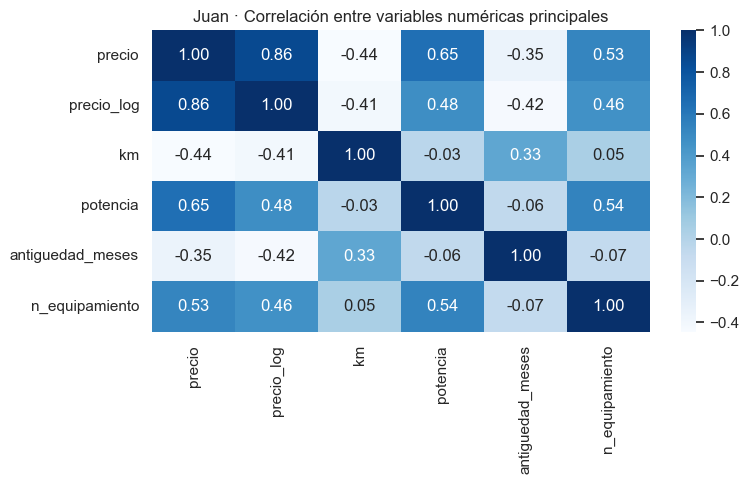

In [21]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_juan, annot=True, fmt=".2f", cmap="Blues")
plt.title("Juan · Correlación entre variables numéricas principales")
plt.tight_layout()
plt.show()


## Juan · 4. Preprocessing para modelado posterior

Objetivo: dejar preparado un dataset numérico que pueda entrar en un modelo en el próximo entregable.

Decisiones sugeridas:

- Eliminar fechas originales porque ya fueron transformadas en variables numéricas.
- Variables categóricas: one-hot encoding.
- Variables booleanas: conversión a 0/1.
- Variables numéricas: escalado estándar para variables continuas.
- Mantener `precio` como target y sacar `precio_log` de las predictoras para evitar fuga de información.


In [22]:
model_ready_juan = features_juan.copy()

# Fechas originales fuera del dataset final de modelado
model_ready_juan = model_ready_juan.drop(columns=["fecha_registro", "fecha_venta"])

# Booleanas a 0/1
for col in boolean_cols_juan:
    if col in model_ready_juan.columns:
        model_ready_juan[col] = model_ready_juan[col].astype(int)

# Categóricas a one-hot
categorical_cols_model_juan = [col for col in ["modelo", "tipo_gasolina", "color", "tipo_coche"] if col in model_ready_juan.columns]
model_ready_juan = pd.get_dummies(model_ready_juan, columns=categorical_cols_model_juan, drop_first=True, dtype=int)

print("Dimensión después de encoding:", model_ready_juan.shape)
pretty_table(model_ready_juan.head())


Dimensión después de encoding: (4837, 116)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van
0,"140,411.00",100.00,1,1,0,0,1,0,1,0,"11,300.00","2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,"13,929.00",187.50,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,"183,297.00",120.00,0,0,0,0,1,0,1,0,"10,200.00","2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,"128,035.00",135.00,1,1,0,0,1,1,1,0,"25,100.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,"97,097.00",160.00,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [23]:
# Separación conceptual de features y target, sin entrenar modelo
TARGET_JUAN = "precio"

y_juan = model_ready_juan[TARGET_JUAN].copy()
X_juan = model_ready_juan.drop(columns=[TARGET_JUAN])

# Dejamos precio_log fuera de X para evitar fuga de información respecto al target precio
if "precio_log" in X_juan.columns:
    X_juan = X_juan.drop(columns=["precio_log"])

# Escalado de numéricas continuas
continuous_cols_juan = ["km", "potencia", "anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses", "n_equipamiento"]
continuous_cols_juan = [col for col in continuous_cols_juan if col in X_juan.columns]

scaler_juan = StandardScaler()
X_scaled_juan = X_juan.copy()
X_scaled_juan[continuous_cols_juan] = scaler_juan.fit_transform(X_scaled_juan[continuous_cols_juan])

# Dataset final preparado con target al final
prepared_juan = pd.concat([X_scaled_juan, y_juan], axis=1)

print("X preparada:", X_scaled_juan.shape)
print("Target:", y_juan.shape)
print("Dataset final preparado:", prepared_juan.shape)
pretty_table(prepared_juan.head())


X preparada: (4837, 114)
Target: (4837,)
Dataset final preparado: (4837, 115)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van,precio
0,0.01,-0.83,1,1,0,0,1,0,1,0,-0.42,-1.71,0.03,-1.82,0.45,0.24,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,"11,300.00"
1,-2.26,1.96,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"30,300.00"
2,0.78,-0.19,0,0,0,0,1,0,1,0,-0.42,-0.87,0.03,-1.36,0.40,-0.93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,"10,200.00"
3,-0.21,0.28,1,1,0,0,1,1,1,0,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,"25,100.00"
4,-0.77,1.08,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-0.43,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,"30,300.00"


## Juan · 5. Validaciones finales y exportación

Objetivo: comprobar que el dataset final cumple con el entregable.

Validaciones:

- No hay nulos.
- No hay duplicados exactos.
- Todas las columnas predictoras son numéricas.
- La variable objetivo está presente.
- Se exporta el dataset limpio/preparado de este bloque.


In [24]:
validation_report_juan = pd.DataFrame({
    "validacion": [
        "Dataset final sin nulos",
        "Dataset final sin duplicados exactos",
        "Variable objetivo presente",
        "Predictoras numéricas",
        "Filas disponibles para modelado",
        "Columnas disponibles para modelado"
    ],
    "resultado": [
        prepared_juan.isna().sum().sum() == 0,
        prepared_juan.duplicated().sum() == 0,
        TARGET_JUAN in prepared_juan.columns,
        all(pd.api.types.is_numeric_dtype(prepared_juan[col]) for col in prepared_juan.drop(columns=[TARGET_JUAN]).columns),
        prepared_juan.shape[0],
        prepared_juan.shape[1]
    ]
})

pretty_table(validation_report_juan)


,validacion,resultado
0,Dataset final sin nulos,True
1,Dataset final sin duplicados exactos,True
2,Variable objetivo presente,True
3,Predictoras numéricas,True
4,Filas disponibles para modelado,"4,837"
5,Columnas disponibles para modelado,115


In [25]:
# Exportación de datasets del bloque de Juan
features_juan.to_csv("bmw_pricing_clean_features_juan.csv", index=False)
prepared_juan.to_csv("bmw_pricing_prepared_model_ready_juan.csv", index=False)

print("Archivos exportados:")
print("- bmw_pricing_clean_features_juan.csv")
print("- bmw_pricing_prepared_model_ready_juan.csv")


Archivos exportados:
- bmw_pricing_clean_features_juan.csv
- bmw_pricing_prepared_model_ready_juan.csv


## Juan · 6. Conclusiones del bloque

Completar al finalizar el trabajo:

- Principales problemas detectados en el dataset.
- Decisiones de limpieza tomadas.
- Estrategia de imputación utilizada.
- Tratamiento de outliers aplicado.
- Variables creadas.
- Limitaciones o supuestos del enfoque.
- Recomendación para la versión final del equipo.


# Workspace · Maxi

Este apartado replica el flujo completo de Data Preparation para que **Maxi** pueda trabajar de punta a punta sin modificar el bloque de otra persona.

Convención de variables de este bloque: todas terminan en `_maxi` para evitar conflictos al ejecutar el notebook completo.


## Maxi · 1. Auditoría inicial del dataset

Objetivo: documentar la estructura inicial del dataset y detectar problemas antes de limpiar.

Preguntas a responder:

- ¿Cuántas filas y columnas hay?
- ¿Qué tipo de dato tiene cada variable?
- ¿Qué columnas tienen valores faltantes?
- ¿Existen duplicados?
- ¿La variable objetivo `precio` está disponible y es válida?


In [26]:
# Copia de trabajo de Maxi
df_maxi = df_raw.copy()

print("Dimensión inicial:", df_maxi.shape)
df_maxi.info()


Dimensión inicial: (4843, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   o

In [27]:
# Resumen de nulos, tipos y cardinalidad
quality_initial_maxi = resumen_calidad(df_maxi)
pretty_table(quality_initial_maxi)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,object,"3,391",70.02,2
4,fecha_registro,object,"2,423",50.03,180
7,tipo_coche,object,"1,460",30.15,8
0,marca,object,970,20.03,1
13,bluetooth,object,728,15.03,2
15,alerta_lim_velocidad,object,728,15.03,2
9,aire_acondicionado,object,486,10.04,2
6,color,object,445,9.19,10
16,precio,float64,6,0.12,437
5,tipo_gasolina,object,5,0.10,5


In [28]:
# Duplicados exactos
duplicados_maxi = df_maxi.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados_maxi}")

if duplicados_maxi > 0:
    display(pretty_table(df_maxi[df_maxi.duplicated()].head(10)))


Filas duplicadas exactas: 0


In [29]:
# Revisión de la variable objetivo
pretty_table(df_maxi[["precio"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
precio,"4,837.00","15,831.92","9,222.63",100.00,"10,800.00","14,200.00","18,600.00","178,500.00"


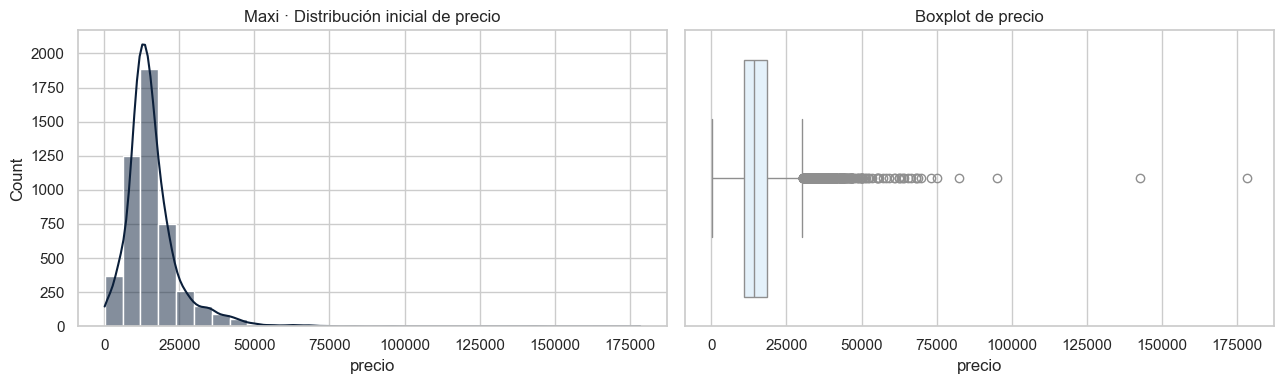

In [30]:
plot_distribution(df_maxi, "precio", "Maxi · Distribución inicial de precio")


### Maxi · 1.1 Diccionario de variables

Completar o ajustar si se detectan interpretaciones distintas de las variables.


In [31]:
data_dictionary_maxi = data_dictionary_base.copy()
pretty_table(data_dictionary_maxi)


,variable,descripcion,tipo_esperado
0,marca,Marca del vehículo,categórica
1,modelo,Modelo del vehículo,categórica
2,km,Kilometraje acumulado,numérica
3,potencia,Potencia del vehículo,numérica
4,fecha_registro,Fecha de registro o matriculación,fecha
5,tipo_gasolina,Tipo de combustible,categórica
6,color,Color del vehículo,categórica
7,tipo_coche,Tipo de carrocería,categórica
8,volante_regulable,Indica si el volante es regulable,booleana
9,aire_acondicionado,Indica si tiene aire acondicionado,booleana


## Maxi · 2. Limpieza de datos

Objetivo: aplicar reglas claras de limpieza, dejando un dataset coherente antes del preprocessing.

Decisiones sugeridas a revisar:

1. Eliminar filas sin `precio`, porque es la variable objetivo del futuro modelo.
2. Eliminar duplicados exactos si existieran.
3. Convertir fechas a tipo datetime.
4. Normalizar columnas booleanas que vienen mezcladas como texto/bool/nulos.
5. Revisar columnas con demasiados nulos y decidir si imputar o eliminar.


In [32]:
# Copia para limpieza
clean_maxi = df_maxi.copy()

# 1) Eliminar registros sin target
rows_before_maxi = clean_maxi.shape[0]
clean_maxi = clean_maxi.dropna(subset=["precio"])
print(f"Filas eliminadas por precio nulo: {rows_before_maxi - clean_maxi.shape[0]}")

# 2) Eliminar duplicados exactos
rows_before_maxi = clean_maxi.shape[0]
clean_maxi = clean_maxi.drop_duplicates()
print(f"Filas duplicadas eliminadas: {rows_before_maxi - clean_maxi.shape[0]}")


Filas eliminadas por precio nulo: 6
Filas duplicadas eliminadas: 0


In [33]:
# 3) Conversión de fechas
for col in ["fecha_registro", "fecha_venta"]:
    clean_maxi[col] = pd.to_datetime(clean_maxi[col], errors="coerce")

pretty_table(clean_maxi[["fecha_registro", "fecha_venta"]].head())


,fecha_registro,fecha_venta
0,2012-02-01 00:00:00,2018-01-01 00:00:00
1,NaT,2018-02-01 00:00:00
2,2012-04-01 00:00:00,2018-02-01 00:00:00
3,NaT,2018-02-01 00:00:00
4,NaT,2018-04-01 00:00:00


In [34]:
# 4) Normalización de variables booleanas
boolean_cols_maxi = [
    "volante_regulable",
    "aire_acondicionado",
    "camara_trasera",
    "asientos_traseros_plegables",
    "elevalunas_electrico",
    "bluetooth",
    "gps",
    "alerta_lim_velocidad"
]

def to_boolean_maxi(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return value
    value_str = str(value).strip().lower()
    if value_str in ["true", "1", "yes", "y", "si", "sí"]:
        return True
    if value_str in ["false", "0", "no", "n"]:
        return False
    return np.nan

for col in boolean_cols_maxi:
    clean_maxi[col] = clean_maxi[col].apply(to_boolean_maxi).astype("boolean")

pretty_table(clean_maxi[boolean_cols_maxi].head())


,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad
0,True,True,False,,True,,True,
1,True,True,False,,False,True,True,True
2,False,False,False,,True,False,True,False
3,True,True,False,,True,True,True,
4,True,True,False,False,False,True,True,True


### Maxi · 2.1 Tratamiento de columnas con alto porcentaje de nulos

Registrar acá el criterio elegido por Maxi.

Criterio sugerido:

- Si una columna aporta poca información o tiene un porcentaje de nulos muy elevado, evaluar su eliminación.
- Si la columna puede tener valor predictivo, conservarla e imputarla.


In [35]:
# Estado luego de limpieza básica
quality_after_basic_cleaning_maxi = resumen_calidad(clean_maxi)
pretty_table(quality_after_basic_cleaning_maxi)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,boolean,"3,388",70.04,2
4,fecha_registro,datetime64[ns],"2,418",49.99,180
7,tipo_coche,object,"1,458",30.14,8
0,marca,object,970,20.05,1
13,bluetooth,boolean,728,15.05,2
15,alerta_lim_velocidad,boolean,728,15.05,2
9,aire_acondicionado,boolean,485,10.03,2
6,color,object,444,9.18,10
5,tipo_gasolina,object,5,0.10,5
8,volante_regulable,boolean,4,0.08,2


In [36]:
# Revisión de marca
if "marca" in clean_maxi.columns:
    display(pretty_table(clean_maxi["marca"].value_counts(dropna=False).rename_axis("marca").reset_index(name="cantidad")))

# Decisión sugerida: eliminar marca porque el caso de estudio se centra en BMW
# Maxi puede comentar esta línea si prefiere conservarla y justificarlo.
if "marca" in clean_maxi.columns:
    clean_maxi = clean_maxi.drop(columns=["marca"])

print("Columnas después del tratamiento de marca:")
print(clean_maxi.columns.tolist())


,marca,cantidad
0,BMW,"3,867"
1,nan,970


Columnas después del tratamiento de marca:
['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta']


### Maxi · 2.2 Imputación de valores faltantes

Registrar acá las decisiones de imputación.

Criterio sugerido:

- Numéricas: mediana.
- Categóricas: `desconocido`.
- Booleanas: `False` como supuesto de característica no informada/no presente.
- Fechas: crear variables temporales y luego imputar las variables derivadas.


In [37]:
# Imputación de categóricas simples
categorical_cols_maxi = ["modelo", "tipo_gasolina", "color", "tipo_coche"]
for col in categorical_cols_maxi:
    if col in clean_maxi.columns:
        clean_maxi[col] = clean_maxi[col].fillna("desconocido").astype(str).str.strip().str.lower()

# Imputación de booleanas
for col in boolean_cols_maxi:
    if col in clean_maxi.columns:
        clean_maxi[col] = clean_maxi[col].fillna(False).astype(bool)

# Imputación de numéricas base
numeric_base_cols_maxi = ["km", "potencia"]
for col in numeric_base_cols_maxi:
    clean_maxi[col] = clean_maxi[col].fillna(clean_maxi[col].median())

pretty_table(resumen_calidad(clean_maxi))


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
3,fecha_registro,datetime64[ns],"2,418",49.99,180
16,fecha_venta,datetime64[ns],1,0.02,13
1,km,float64,0,0.00,"4,778"
15,precio,float64,0,0.00,437
0,modelo,object,0,0.00,77
2,potencia,float64,0,0.00,61
5,color,object,0,0.00,11
6,tipo_coche,object,0,0.00,9
4,tipo_gasolina,object,0,0.00,5
7,volante_regulable,bool,0,0.00,2


### Maxi · 2.3 Tratamiento de outliers

Para este entregable, el tratamiento debe ser conservador porque todavía no se modela.

Propuesta base: winsorización por IQR en `precio`, `km` y `potencia`.


In [38]:
def winsorize_iqr_maxi(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower=lower, upper=upper), lower, upper

outlier_limits_maxi = []
for col in ["precio", "km", "potencia"]:
    clean_maxi[col], lower, upper = winsorize_iqr_maxi(clean_maxi[col])
    outlier_limits_maxi.append({"variable": col, "limite_inferior": lower, "limite_superior": upper})

outlier_limits_maxi = pd.DataFrame(outlier_limits_maxi)
pretty_table(outlier_limits_maxi)


,variable,limite_inferior,limite_superior
0,precio,-900.00,"30,300.00"
1,km,"-5,642.50","283,761.50"
2,potencia,47.50,187.50


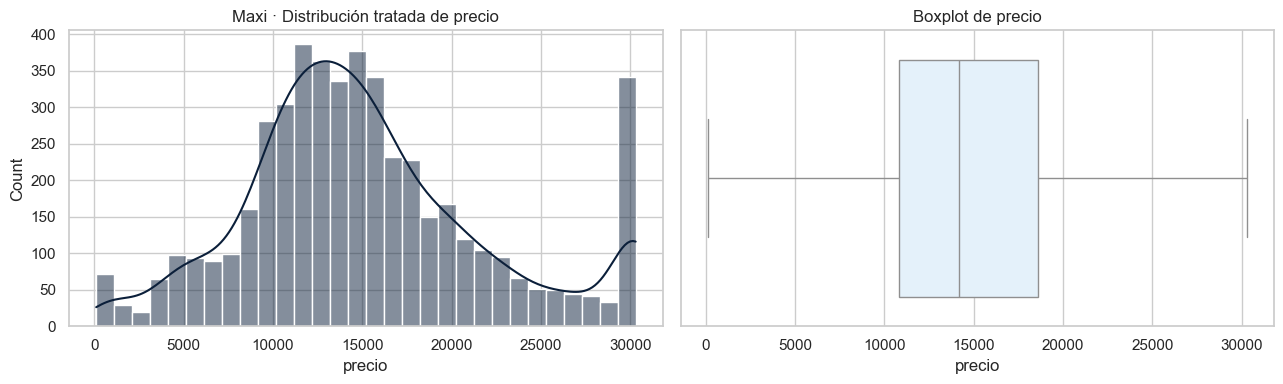

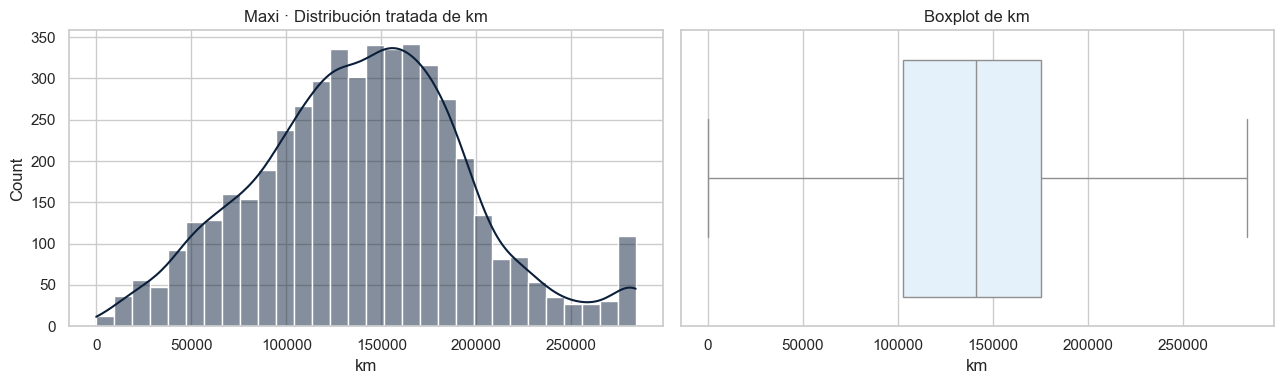

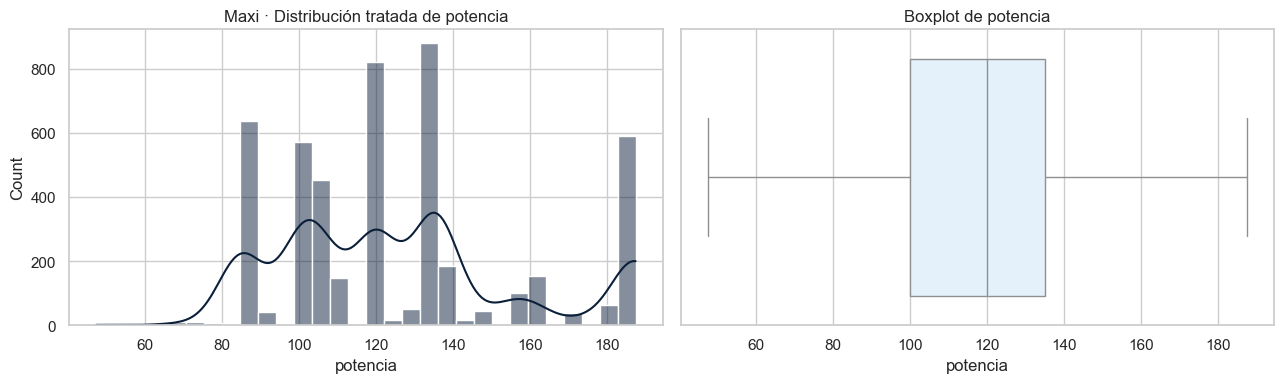

In [39]:
for col in ["precio", "km", "potencia"]:
    plot_distribution(clean_maxi, col, f"Maxi · Distribución tratada de {col}")


## Maxi · 3. Feature engineering

Objetivo: crear variables útiles para modelado sin entrenar ningún modelo.

Variables derivadas propuestas:

- `antiguedad_meses`: diferencia entre fecha de venta y fecha de registro.
- `anio_registro` y `mes_registro`.
- `anio_venta` y `mes_venta`.
- `precio_log`: transformación logarítmica de la variable objetivo para análisis futuro.
- `n_equipamiento`: cantidad de características booleanas presentes.


In [40]:
features_maxi = clean_maxi.copy()

# Variables temporales
features_maxi["anio_registro"] = features_maxi["fecha_registro"].dt.year
features_maxi["mes_registro"] = features_maxi["fecha_registro"].dt.month
features_maxi["anio_venta"] = features_maxi["fecha_venta"].dt.year
features_maxi["mes_venta"] = features_maxi["fecha_venta"].dt.month

# Antigüedad en meses
features_maxi["antiguedad_meses"] = (
    (features_maxi["fecha_venta"].dt.year - features_maxi["fecha_registro"].dt.year) * 12 +
    (features_maxi["fecha_venta"].dt.month - features_maxi["fecha_registro"].dt.month)
)

# Si por nulos o errores queda antigüedad negativa, se reemplaza por NaN antes de imputar
features_maxi.loc[features_maxi["antiguedad_meses"] < 0, "antiguedad_meses"] = np.nan

# Imputación de variables temporales derivadas
for col in ["anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses"]:
    features_maxi[col] = features_maxi[col].fillna(features_maxi[col].median())

# Transformación de target para análisis futuro
features_maxi["precio_log"] = np.log1p(features_maxi["precio"])

# Conteo de equipamiento
features_maxi["n_equipamiento"] = features_maxi[boolean_cols_maxi].sum(axis=1)

pretty_table(features_maxi.head())


,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento
0,118,"140,411.00",100.00,2012-02-01 00:00:00,diesel,black,desconocido,True,True,False,False,True,False,True,False,"11,300.00",2018-01-01 00:00:00,"2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4
1,m4,"13,929.00",187.50,NaT,petrol,grey,convertible,True,True,False,False,False,True,True,True,"30,300.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5
2,320,"183,297.00",120.00,2012-04-01 00:00:00,diesel,white,desconocido,False,False,False,False,True,False,True,False,"10,200.00",2018-02-01 00:00:00,"2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2
3,420,"128,035.00",135.00,NaT,diesel,red,convertible,True,True,False,False,True,True,True,False,"25,100.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5
4,425,"97,097.00",160.00,NaT,diesel,silver,desconocido,True,True,False,False,False,True,True,True,"30,300.00",2018-04-01 00:00:00,"2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5


In [41]:
# Revisión de correlaciones numéricas con precio
numeric_for_corr_maxi = ["precio", "precio_log", "km", "potencia", "antiguedad_meses", "n_equipamiento"]
corr_maxi = features_maxi[numeric_for_corr_maxi].corr(numeric_only=True)
pretty_table(corr_maxi)


,precio,precio_log,km,potencia,antiguedad_meses,n_equipamiento
precio,1.00,0.86,-0.44,0.65,-0.35,0.53
precio_log,0.86,1.00,-0.41,0.48,-0.42,0.46
km,-0.44,-0.41,1.00,-0.03,0.33,0.05
potencia,0.65,0.48,-0.03,1.00,-0.06,0.54
antiguedad_meses,-0.35,-0.42,0.33,-0.06,1.00,-0.07
n_equipamiento,0.53,0.46,0.05,0.54,-0.07,1.00


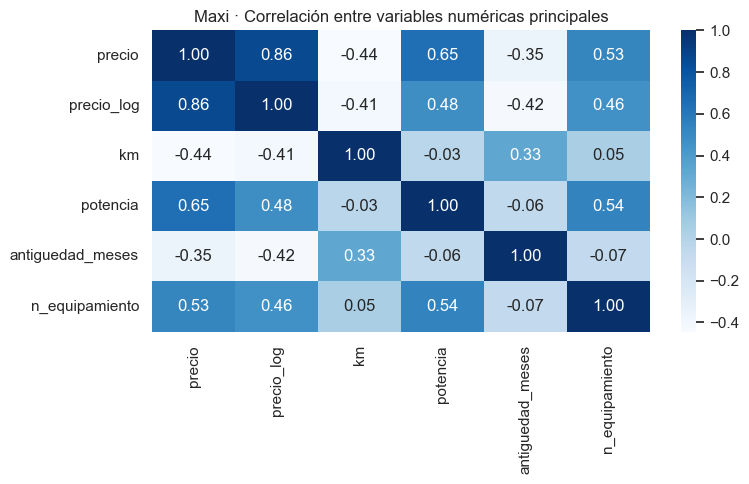

In [42]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_maxi, annot=True, fmt=".2f", cmap="Blues")
plt.title("Maxi · Correlación entre variables numéricas principales")
plt.tight_layout()
plt.show()


## Maxi · 4. Preprocessing para modelado posterior

Objetivo: dejar preparado un dataset numérico que pueda entrar en un modelo en el próximo entregable.

Decisiones sugeridas:

- Eliminar fechas originales porque ya fueron transformadas en variables numéricas.
- Variables categóricas: one-hot encoding.
- Variables booleanas: conversión a 0/1.
- Variables numéricas: escalado estándar para variables continuas.
- Mantener `precio` como target y sacar `precio_log` de las predictoras para evitar fuga de información.


In [43]:
model_ready_maxi = features_maxi.copy()

# Fechas originales fuera del dataset final de modelado
model_ready_maxi = model_ready_maxi.drop(columns=["fecha_registro", "fecha_venta"])

# Booleanas a 0/1
for col in boolean_cols_maxi:
    if col in model_ready_maxi.columns:
        model_ready_maxi[col] = model_ready_maxi[col].astype(int)

# Categóricas a one-hot
categorical_cols_model_maxi = [col for col in ["modelo", "tipo_gasolina", "color", "tipo_coche"] if col in model_ready_maxi.columns]
model_ready_maxi = pd.get_dummies(model_ready_maxi, columns=categorical_cols_model_maxi, drop_first=True, dtype=int)

print("Dimensión después de encoding:", model_ready_maxi.shape)
pretty_table(model_ready_maxi.head())


Dimensión después de encoding: (4837, 116)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van
0,"140,411.00",100.00,1,1,0,0,1,0,1,0,"11,300.00","2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,"13,929.00",187.50,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,"183,297.00",120.00,0,0,0,0,1,0,1,0,"10,200.00","2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,"128,035.00",135.00,1,1,0,0,1,1,1,0,"25,100.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,"97,097.00",160.00,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [44]:
# Separación conceptual de features y target, sin entrenar modelo
TARGET_MAXI = "precio"

y_maxi = model_ready_maxi[TARGET_MAXI].copy()
X_maxi = model_ready_maxi.drop(columns=[TARGET_MAXI])

# Dejamos precio_log fuera de X para evitar fuga de información respecto al target precio
if "precio_log" in X_maxi.columns:
    X_maxi = X_maxi.drop(columns=["precio_log"])

# Escalado de numéricas continuas
continuous_cols_maxi = ["km", "potencia", "anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses", "n_equipamiento"]
continuous_cols_maxi = [col for col in continuous_cols_maxi if col in X_maxi.columns]

scaler_maxi = StandardScaler()
X_scaled_maxi = X_maxi.copy()
X_scaled_maxi[continuous_cols_maxi] = scaler_maxi.fit_transform(X_scaled_maxi[continuous_cols_maxi])

# Dataset final preparado con target al final
prepared_maxi = pd.concat([X_scaled_maxi, y_maxi], axis=1)

print("X preparada:", X_scaled_maxi.shape)
print("Target:", y_maxi.shape)
print("Dataset final preparado:", prepared_maxi.shape)
pretty_table(prepared_maxi.head())


X preparada: (4837, 114)
Target: (4837,)
Dataset final preparado: (4837, 115)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van,precio
0,0.01,-0.83,1,1,0,0,1,0,1,0,-0.42,-1.71,0.03,-1.82,0.45,0.24,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,"11,300.00"
1,-2.26,1.96,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"30,300.00"
2,0.78,-0.19,0,0,0,0,1,0,1,0,-0.42,-0.87,0.03,-1.36,0.40,-0.93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,"10,200.00"
3,-0.21,0.28,1,1,0,0,1,1,1,0,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,"25,100.00"
4,-0.77,1.08,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-0.43,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,"30,300.00"


## Maxi · 5. Validaciones finales y exportación

Objetivo: comprobar que el dataset final cumple con el entregable.

Validaciones:

- No hay nulos.
- No hay duplicados exactos.
- Todas las columnas predictoras son numéricas.
- La variable objetivo está presente.
- Se exporta el dataset limpio/preparado de este bloque.


In [45]:
validation_report_maxi = pd.DataFrame({
    "validacion": [
        "Dataset final sin nulos",
        "Dataset final sin duplicados exactos",
        "Variable objetivo presente",
        "Predictoras numéricas",
        "Filas disponibles para modelado",
        "Columnas disponibles para modelado"
    ],
    "resultado": [
        prepared_maxi.isna().sum().sum() == 0,
        prepared_maxi.duplicated().sum() == 0,
        TARGET_MAXI in prepared_maxi.columns,
        all(pd.api.types.is_numeric_dtype(prepared_maxi[col]) for col in prepared_maxi.drop(columns=[TARGET_MAXI]).columns),
        prepared_maxi.shape[0],
        prepared_maxi.shape[1]
    ]
})

pretty_table(validation_report_maxi)


,validacion,resultado
0,Dataset final sin nulos,True
1,Dataset final sin duplicados exactos,True
2,Variable objetivo presente,True
3,Predictoras numéricas,True
4,Filas disponibles para modelado,"4,837"
5,Columnas disponibles para modelado,115


In [46]:
# Exportación de datasets del bloque de Maxi
features_maxi.to_csv("bmw_pricing_clean_features_maxi.csv", index=False)
prepared_maxi.to_csv("bmw_pricing_prepared_model_ready_maxi.csv", index=False)

print("Archivos exportados:")
print("- bmw_pricing_clean_features_maxi.csv")
print("- bmw_pricing_prepared_model_ready_maxi.csv")


Archivos exportados:
- bmw_pricing_clean_features_maxi.csv
- bmw_pricing_prepared_model_ready_maxi.csv


## Maxi · 6. Conclusiones del bloque

Completar al finalizar el trabajo:

- Principales problemas detectados en el dataset.
- Decisiones de limpieza tomadas.
- Estrategia de imputación utilizada.
- Tratamiento de outliers aplicado.
- Variables creadas.
- Limitaciones o supuestos del enfoque.
- Recomendación para la versión final del equipo.


# Workspace · Carmen

Este apartado replica el flujo completo de Data Preparation para que **Carmen** pueda trabajar de punta a punta sin modificar el bloque de otra persona.

Convención de variables de este bloque: todas terminan en `_carmen` para evitar conflictos al ejecutar el notebook completo.


## Carmen · 1. Auditoría inicial del dataset

Objetivo: documentar la estructura inicial del dataset y detectar problemas antes de limpiar.

Preguntas a responder:

- ¿Cuántas filas y columnas hay?
- ¿Qué tipo de dato tiene cada variable?
- ¿Qué columnas tienen valores faltantes?
- ¿Existen duplicados?
- ¿La variable objetivo `precio` está disponible y es válida?


In [47]:
# Copia de trabajo de Carmen
df_carmen = df_raw.copy()

print("Dimensión inicial:", df_carmen.shape)
df_carmen.info()


Dimensión inicial: (4843, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   o

In [48]:
# Resumen de nulos, tipos y cardinalidad
quality_initial_carmen = resumen_calidad(df_carmen)
pretty_table(quality_initial_carmen)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,object,"3,391",70.02,2
4,fecha_registro,object,"2,423",50.03,180
7,tipo_coche,object,"1,460",30.15,8
0,marca,object,970,20.03,1
13,bluetooth,object,728,15.03,2
15,alerta_lim_velocidad,object,728,15.03,2
9,aire_acondicionado,object,486,10.04,2
6,color,object,445,9.19,10
16,precio,float64,6,0.12,437
5,tipo_gasolina,object,5,0.10,5


In [49]:
# Duplicados exactos
duplicados_carmen = df_carmen.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados_carmen}")

if duplicados_carmen > 0:
    display(pretty_table(df_carmen[df_carmen.duplicated()].head(10)))


Filas duplicadas exactas: 0


In [50]:
# Revisión de la variable objetivo
pretty_table(df_carmen[["precio"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
precio,"4,837.00","15,831.92","9,222.63",100.00,"10,800.00","14,200.00","18,600.00","178,500.00"


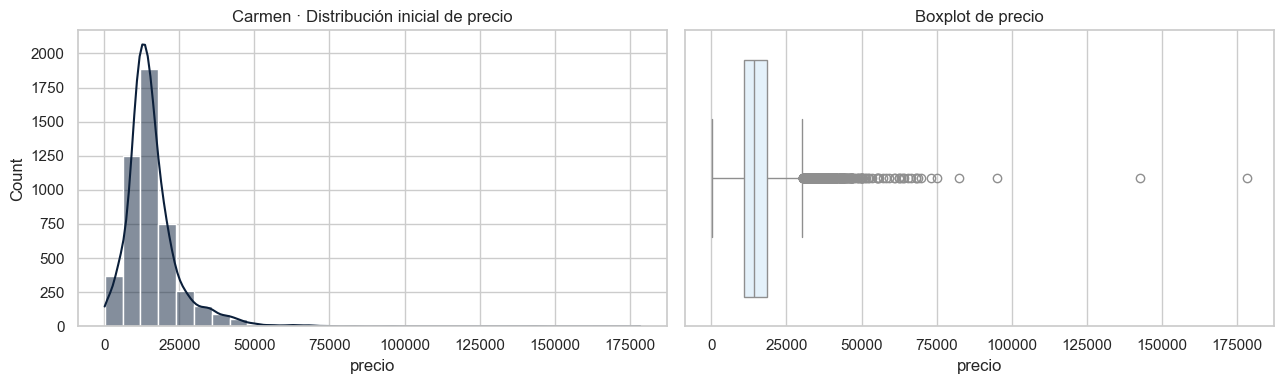

In [51]:
plot_distribution(df_carmen, "precio", "Carmen · Distribución inicial de precio")


### Carmen · 1.1 Diccionario de variables

Completar o ajustar si se detectan interpretaciones distintas de las variables.


In [52]:
data_dictionary_carmen = data_dictionary_base.copy()
pretty_table(data_dictionary_carmen)


,variable,descripcion,tipo_esperado
0,marca,Marca del vehículo,categórica
1,modelo,Modelo del vehículo,categórica
2,km,Kilometraje acumulado,numérica
3,potencia,Potencia del vehículo,numérica
4,fecha_registro,Fecha de registro o matriculación,fecha
5,tipo_gasolina,Tipo de combustible,categórica
6,color,Color del vehículo,categórica
7,tipo_coche,Tipo de carrocería,categórica
8,volante_regulable,Indica si el volante es regulable,booleana
9,aire_acondicionado,Indica si tiene aire acondicionado,booleana


## Carmen · 2. Limpieza de datos

Objetivo: aplicar reglas claras de limpieza, dejando un dataset coherente antes del preprocessing.

Decisiones sugeridas a revisar:

1. Eliminar filas sin `precio`, porque es la variable objetivo del futuro modelo.
2. Eliminar duplicados exactos si existieran.
3. Convertir fechas a tipo datetime.
4. Normalizar columnas booleanas que vienen mezcladas como texto/bool/nulos.
5. Revisar columnas con demasiados nulos y decidir si imputar o eliminar.


In [53]:
# Copia para limpieza
clean_carmen = df_carmen.copy()

# 1) Eliminar registros sin target
rows_before_carmen = clean_carmen.shape[0]
clean_carmen = clean_carmen.dropna(subset=["precio"])
print(f"Filas eliminadas por precio nulo: {rows_before_carmen - clean_carmen.shape[0]}")

# 2) Eliminar duplicados exactos
rows_before_carmen = clean_carmen.shape[0]
clean_carmen = clean_carmen.drop_duplicates()
print(f"Filas duplicadas eliminadas: {rows_before_carmen - clean_carmen.shape[0]}")


Filas eliminadas por precio nulo: 6
Filas duplicadas eliminadas: 0


In [54]:
# 3) Conversión de fechas
for col in ["fecha_registro", "fecha_venta"]:
    clean_carmen[col] = pd.to_datetime(clean_carmen[col], errors="coerce")

pretty_table(clean_carmen[["fecha_registro", "fecha_venta"]].head())


,fecha_registro,fecha_venta
0,2012-02-01 00:00:00,2018-01-01 00:00:00
1,NaT,2018-02-01 00:00:00
2,2012-04-01 00:00:00,2018-02-01 00:00:00
3,NaT,2018-02-01 00:00:00
4,NaT,2018-04-01 00:00:00


In [55]:
# 4) Normalización de variables booleanas
boolean_cols_carmen = [
    "volante_regulable",
    "aire_acondicionado",
    "camara_trasera",
    "asientos_traseros_plegables",
    "elevalunas_electrico",
    "bluetooth",
    "gps",
    "alerta_lim_velocidad"
]

def to_boolean_carmen(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return value
    value_str = str(value).strip().lower()
    if value_str in ["true", "1", "yes", "y", "si", "sí"]:
        return True
    if value_str in ["false", "0", "no", "n"]:
        return False
    return np.nan

for col in boolean_cols_carmen:
    clean_carmen[col] = clean_carmen[col].apply(to_boolean_carmen).astype("boolean")

pretty_table(clean_carmen[boolean_cols_carmen].head())


,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad
0,True,True,False,,True,,True,
1,True,True,False,,False,True,True,True
2,False,False,False,,True,False,True,False
3,True,True,False,,True,True,True,
4,True,True,False,False,False,True,True,True


### Carmen · 2.1 Tratamiento de columnas con alto porcentaje de nulos

Registrar acá el criterio elegido por Carmen.

Criterio sugerido:

- Si una columna aporta poca información o tiene un porcentaje de nulos muy elevado, evaluar su eliminación.
- Si la columna puede tener valor predictivo, conservarla e imputarla.


In [56]:
# Estado luego de limpieza básica
quality_after_basic_cleaning_carmen = resumen_calidad(clean_carmen)
pretty_table(quality_after_basic_cleaning_carmen)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,boolean,"3,388",70.04,2
4,fecha_registro,datetime64[ns],"2,418",49.99,180
7,tipo_coche,object,"1,458",30.14,8
0,marca,object,970,20.05,1
13,bluetooth,boolean,728,15.05,2
15,alerta_lim_velocidad,boolean,728,15.05,2
9,aire_acondicionado,boolean,485,10.03,2
6,color,object,444,9.18,10
5,tipo_gasolina,object,5,0.10,5
8,volante_regulable,boolean,4,0.08,2


In [57]:
# Revisión de marca
if "marca" in clean_carmen.columns:
    display(pretty_table(clean_carmen["marca"].value_counts(dropna=False).rename_axis("marca").reset_index(name="cantidad")))

# Decisión sugerida: eliminar marca porque el caso de estudio se centra en BMW
# Carmen puede comentar esta línea si prefiere conservarla y justificarlo.
if "marca" in clean_carmen.columns:
    clean_carmen = clean_carmen.drop(columns=["marca"])

print("Columnas después del tratamiento de marca:")
print(clean_carmen.columns.tolist())


,marca,cantidad
0,BMW,"3,867"
1,nan,970


Columnas después del tratamiento de marca:
['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta']


### Carmen · 2.2 Imputación de valores faltantes

Registrar acá las decisiones de imputación.

Criterio sugerido:

- Numéricas: mediana.
- Categóricas: `desconocido`.
- Booleanas: `False` como supuesto de característica no informada/no presente.
- Fechas: crear variables temporales y luego imputar las variables derivadas.


In [58]:
# Imputación de categóricas simples
categorical_cols_carmen = ["modelo", "tipo_gasolina", "color", "tipo_coche"]
for col in categorical_cols_carmen:
    if col in clean_carmen.columns:
        clean_carmen[col] = clean_carmen[col].fillna("desconocido").astype(str).str.strip().str.lower()

# Imputación de booleanas
for col in boolean_cols_carmen:
    if col in clean_carmen.columns:
        clean_carmen[col] = clean_carmen[col].fillna(False).astype(bool)

# Imputación de numéricas base
numeric_base_cols_carmen = ["km", "potencia"]
for col in numeric_base_cols_carmen:
    clean_carmen[col] = clean_carmen[col].fillna(clean_carmen[col].median())

pretty_table(resumen_calidad(clean_carmen))


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
3,fecha_registro,datetime64[ns],"2,418",49.99,180
16,fecha_venta,datetime64[ns],1,0.02,13
1,km,float64,0,0.00,"4,778"
15,precio,float64,0,0.00,437
0,modelo,object,0,0.00,77
2,potencia,float64,0,0.00,61
5,color,object,0,0.00,11
6,tipo_coche,object,0,0.00,9
4,tipo_gasolina,object,0,0.00,5
7,volante_regulable,bool,0,0.00,2


### Carmen · 2.3 Tratamiento de outliers

Para este entregable, el tratamiento debe ser conservador porque todavía no se modela.

Propuesta base: winsorización por IQR en `precio`, `km` y `potencia`.


In [59]:
def winsorize_iqr_carmen(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower=lower, upper=upper), lower, upper

outlier_limits_carmen = []
for col in ["precio", "km", "potencia"]:
    clean_carmen[col], lower, upper = winsorize_iqr_carmen(clean_carmen[col])
    outlier_limits_carmen.append({"variable": col, "limite_inferior": lower, "limite_superior": upper})

outlier_limits_carmen = pd.DataFrame(outlier_limits_carmen)
pretty_table(outlier_limits_carmen)


,variable,limite_inferior,limite_superior
0,precio,-900.00,"30,300.00"
1,km,"-5,642.50","283,761.50"
2,potencia,47.50,187.50


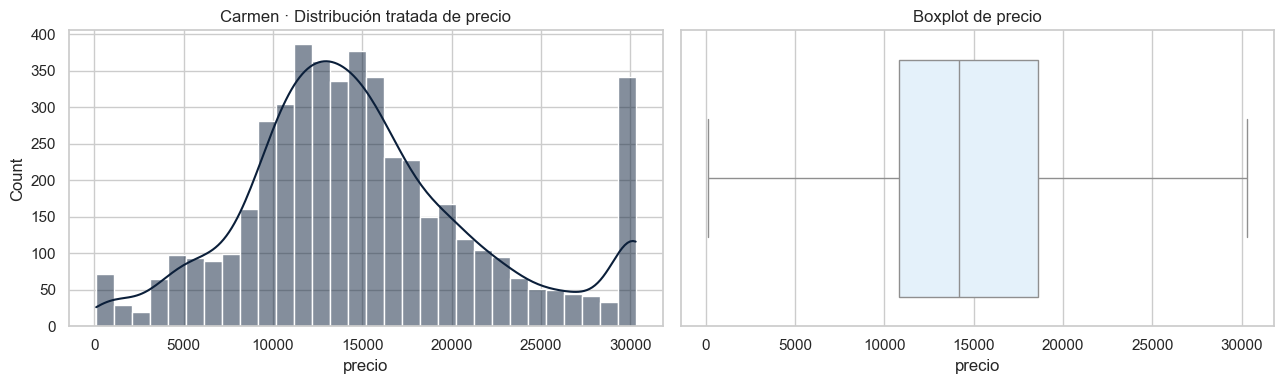

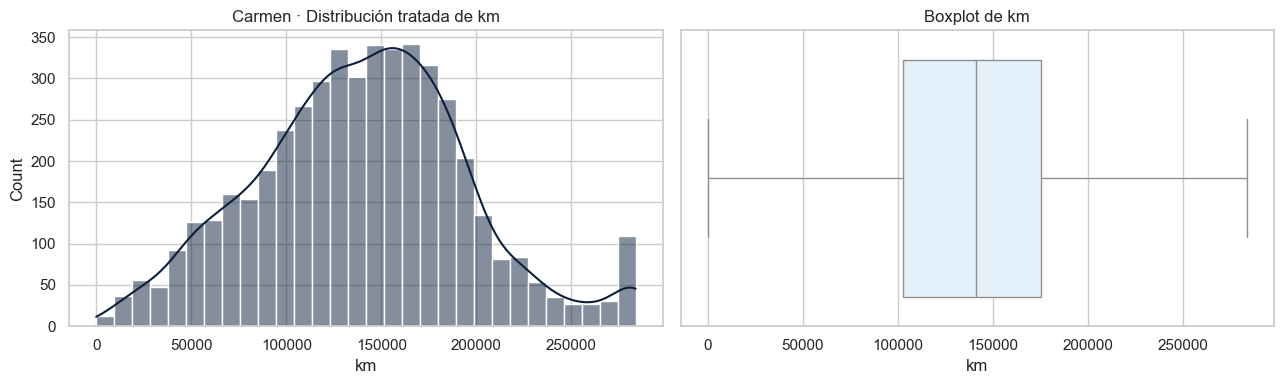

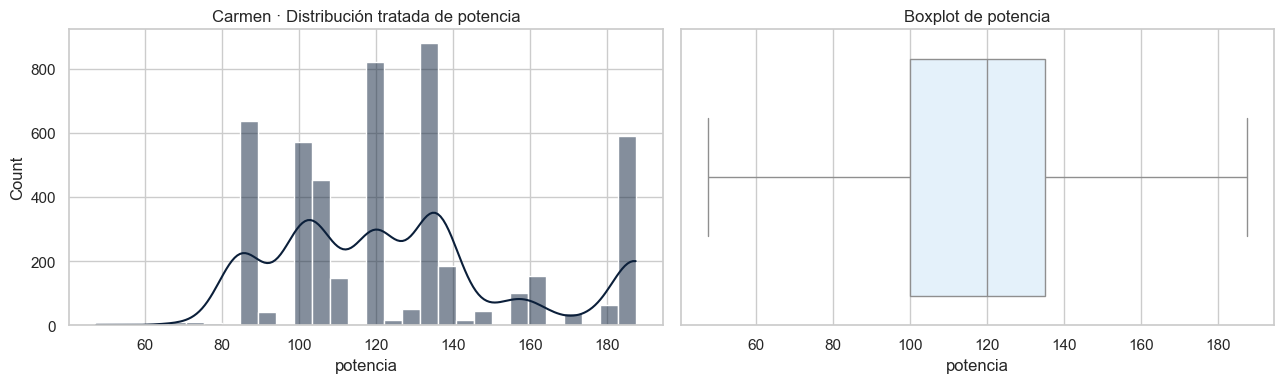

In [60]:
for col in ["precio", "km", "potencia"]:
    plot_distribution(clean_carmen, col, f"Carmen · Distribución tratada de {col}")


## Carmen · 3. Feature engineering

Objetivo: crear variables útiles para modelado sin entrenar ningún modelo.

Variables derivadas propuestas:

- `antiguedad_meses`: diferencia entre fecha de venta y fecha de registro.
- `anio_registro` y `mes_registro`.
- `anio_venta` y `mes_venta`.
- `precio_log`: transformación logarítmica de la variable objetivo para análisis futuro.
- `n_equipamiento`: cantidad de características booleanas presentes.


In [61]:
features_carmen = clean_carmen.copy()

# Variables temporales
features_carmen["anio_registro"] = features_carmen["fecha_registro"].dt.year
features_carmen["mes_registro"] = features_carmen["fecha_registro"].dt.month
features_carmen["anio_venta"] = features_carmen["fecha_venta"].dt.year
features_carmen["mes_venta"] = features_carmen["fecha_venta"].dt.month

# Antigüedad en meses
features_carmen["antiguedad_meses"] = (
    (features_carmen["fecha_venta"].dt.year - features_carmen["fecha_registro"].dt.year) * 12 +
    (features_carmen["fecha_venta"].dt.month - features_carmen["fecha_registro"].dt.month)
)

# Si por nulos o errores queda antigüedad negativa, se reemplaza por NaN antes de imputar
features_carmen.loc[features_carmen["antiguedad_meses"] < 0, "antiguedad_meses"] = np.nan

# Imputación de variables temporales derivadas
for col in ["anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses"]:
    features_carmen[col] = features_carmen[col].fillna(features_carmen[col].median())

# Transformación de target para análisis futuro
features_carmen["precio_log"] = np.log1p(features_carmen["precio"])

# Conteo de equipamiento
features_carmen["n_equipamiento"] = features_carmen[boolean_cols_carmen].sum(axis=1)

pretty_table(features_carmen.head())


,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento
0,118,"140,411.00",100.00,2012-02-01 00:00:00,diesel,black,desconocido,True,True,False,False,True,False,True,False,"11,300.00",2018-01-01 00:00:00,"2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4
1,m4,"13,929.00",187.50,NaT,petrol,grey,convertible,True,True,False,False,False,True,True,True,"30,300.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5
2,320,"183,297.00",120.00,2012-04-01 00:00:00,diesel,white,desconocido,False,False,False,False,True,False,True,False,"10,200.00",2018-02-01 00:00:00,"2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2
3,420,"128,035.00",135.00,NaT,diesel,red,convertible,True,True,False,False,True,True,True,False,"25,100.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5
4,425,"97,097.00",160.00,NaT,diesel,silver,desconocido,True,True,False,False,False,True,True,True,"30,300.00",2018-04-01 00:00:00,"2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5


In [62]:
# Revisión de correlaciones numéricas con precio
numeric_for_corr_carmen = ["precio", "precio_log", "km", "potencia", "antiguedad_meses", "n_equipamiento"]
corr_carmen = features_carmen[numeric_for_corr_carmen].corr(numeric_only=True)
pretty_table(corr_carmen)


,precio,precio_log,km,potencia,antiguedad_meses,n_equipamiento
precio,1.00,0.86,-0.44,0.65,-0.35,0.53
precio_log,0.86,1.00,-0.41,0.48,-0.42,0.46
km,-0.44,-0.41,1.00,-0.03,0.33,0.05
potencia,0.65,0.48,-0.03,1.00,-0.06,0.54
antiguedad_meses,-0.35,-0.42,0.33,-0.06,1.00,-0.07
n_equipamiento,0.53,0.46,0.05,0.54,-0.07,1.00


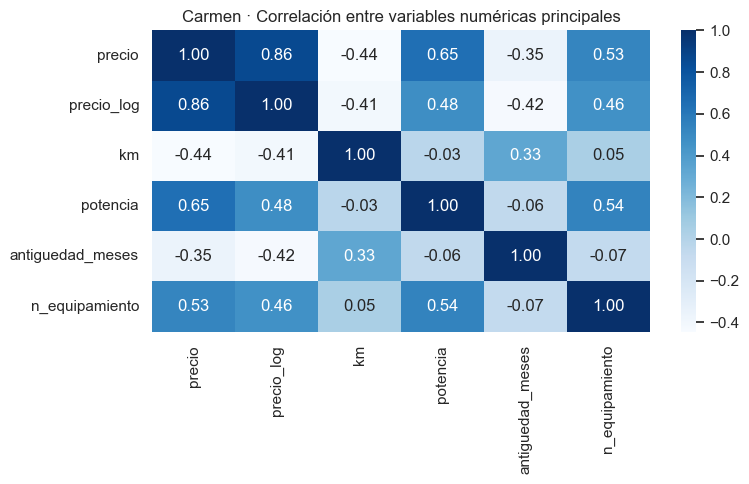

In [63]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_carmen, annot=True, fmt=".2f", cmap="Blues")
plt.title("Carmen · Correlación entre variables numéricas principales")
plt.tight_layout()
plt.show()


## Carmen · 4. Preprocessing para modelado posterior

Objetivo: dejar preparado un dataset numérico que pueda entrar en un modelo en el próximo entregable.

Decisiones sugeridas:

- Eliminar fechas originales porque ya fueron transformadas en variables numéricas.
- Variables categóricas: one-hot encoding.
- Variables booleanas: conversión a 0/1.
- Variables numéricas: escalado estándar para variables continuas.
- Mantener `precio` como target y sacar `precio_log` de las predictoras para evitar fuga de información.


In [64]:
model_ready_carmen = features_carmen.copy()

# Fechas originales fuera del dataset final de modelado
model_ready_carmen = model_ready_carmen.drop(columns=["fecha_registro", "fecha_venta"])

# Booleanas a 0/1
for col in boolean_cols_carmen:
    if col in model_ready_carmen.columns:
        model_ready_carmen[col] = model_ready_carmen[col].astype(int)

# Categóricas a one-hot
categorical_cols_model_carmen = [col for col in ["modelo", "tipo_gasolina", "color", "tipo_coche"] if col in model_ready_carmen.columns]
model_ready_carmen = pd.get_dummies(model_ready_carmen, columns=categorical_cols_model_carmen, drop_first=True, dtype=int)

print("Dimensión después de encoding:", model_ready_carmen.shape)
pretty_table(model_ready_carmen.head())


Dimensión después de encoding: (4837, 116)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van
0,"140,411.00",100.00,1,1,0,0,1,0,1,0,"11,300.00","2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,"13,929.00",187.50,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,"183,297.00",120.00,0,0,0,0,1,0,1,0,"10,200.00","2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,"128,035.00",135.00,1,1,0,0,1,1,1,0,"25,100.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,"97,097.00",160.00,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [65]:
# Separación conceptual de features y target, sin entrenar modelo
TARGET_CARMEN = "precio"

y_carmen = model_ready_carmen[TARGET_CARMEN].copy()
X_carmen = model_ready_carmen.drop(columns=[TARGET_CARMEN])

# Dejamos precio_log fuera de X para evitar fuga de información respecto al target precio
if "precio_log" in X_carmen.columns:
    X_carmen = X_carmen.drop(columns=["precio_log"])

# Escalado de numéricas continuas
continuous_cols_carmen = ["km", "potencia", "anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses", "n_equipamiento"]
continuous_cols_carmen = [col for col in continuous_cols_carmen if col in X_carmen.columns]

scaler_carmen = StandardScaler()
X_scaled_carmen = X_carmen.copy()
X_scaled_carmen[continuous_cols_carmen] = scaler_carmen.fit_transform(X_scaled_carmen[continuous_cols_carmen])

# Dataset final preparado con target al final
prepared_carmen = pd.concat([X_scaled_carmen, y_carmen], axis=1)

print("X preparada:", X_scaled_carmen.shape)
print("Target:", y_carmen.shape)
print("Dataset final preparado:", prepared_carmen.shape)
pretty_table(prepared_carmen.head())


X preparada: (4837, 114)
Target: (4837,)
Dataset final preparado: (4837, 115)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van,precio
0,0.01,-0.83,1,1,0,0,1,0,1,0,-0.42,-1.71,0.03,-1.82,0.45,0.24,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,"11,300.00"
1,-2.26,1.96,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"30,300.00"
2,0.78,-0.19,0,0,0,0,1,0,1,0,-0.42,-0.87,0.03,-1.36,0.40,-0.93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,"10,200.00"
3,-0.21,0.28,1,1,0,0,1,1,1,0,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,"25,100.00"
4,-0.77,1.08,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-0.43,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,"30,300.00"


## Carmen · 5. Validaciones finales y exportación

Objetivo: comprobar que el dataset final cumple con el entregable.

Validaciones:

- No hay nulos.
- No hay duplicados exactos.
- Todas las columnas predictoras son numéricas.
- La variable objetivo está presente.
- Se exporta el dataset limpio/preparado de este bloque.


In [66]:
validation_report_carmen = pd.DataFrame({
    "validacion": [
        "Dataset final sin nulos",
        "Dataset final sin duplicados exactos",
        "Variable objetivo presente",
        "Predictoras numéricas",
        "Filas disponibles para modelado",
        "Columnas disponibles para modelado"
    ],
    "resultado": [
        prepared_carmen.isna().sum().sum() == 0,
        prepared_carmen.duplicated().sum() == 0,
        TARGET_CARMEN in prepared_carmen.columns,
        all(pd.api.types.is_numeric_dtype(prepared_carmen[col]) for col in prepared_carmen.drop(columns=[TARGET_CARMEN]).columns),
        prepared_carmen.shape[0],
        prepared_carmen.shape[1]
    ]
})

pretty_table(validation_report_carmen)


,validacion,resultado
0,Dataset final sin nulos,True
1,Dataset final sin duplicados exactos,True
2,Variable objetivo presente,True
3,Predictoras numéricas,True
4,Filas disponibles para modelado,"4,837"
5,Columnas disponibles para modelado,115


In [67]:
# Exportación de datasets del bloque de Carmen
features_carmen.to_csv("bmw_pricing_clean_features_carmen.csv", index=False)
prepared_carmen.to_csv("bmw_pricing_prepared_model_ready_carmen.csv", index=False)

print("Archivos exportados:")
print("- bmw_pricing_clean_features_carmen.csv")
print("- bmw_pricing_prepared_model_ready_carmen.csv")


Archivos exportados:
- bmw_pricing_clean_features_carmen.csv
- bmw_pricing_prepared_model_ready_carmen.csv


## Carmen · 6. Conclusiones del bloque

Completar al finalizar el trabajo:

- Principales problemas detectados en el dataset.
- Decisiones de limpieza tomadas.
- Estrategia de imputación utilizada.
- Tratamiento de outliers aplicado.
- Variables creadas.
- Limitaciones o supuestos del enfoque.
- Recomendación para la versión final del equipo.


# Workspace · Adria

Este apartado replica el flujo completo de Data Preparation para que **Adria** pueda trabajar de punta a punta sin modificar el bloque de otra persona.

Convención de variables de este bloque: todas terminan en `_adria` para evitar conflictos al ejecutar el notebook completo.


## Adria · 1. Auditoría inicial del dataset

Objetivo: documentar la estructura inicial del dataset y detectar problemas antes de limpiar.

Preguntas a responder:

- ¿Cuántas filas y columnas hay?
- ¿Qué tipo de dato tiene cada variable?
- ¿Qué columnas tienen valores faltantes?
- ¿Existen duplicados?
- ¿La variable objetivo `precio` está disponible y es válida?


In [68]:
# Copia de trabajo de Adria
df_adria = df_raw.copy()

print("Dimensión inicial:", df_adria.shape)
df_adria.info()


Dimensión inicial: (4843, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   o

In [69]:
# Resumen de nulos, tipos y cardinalidad
quality_initial_adria = resumen_calidad(df_adria)
pretty_table(quality_initial_adria)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,object,"3,391",70.02,2
4,fecha_registro,object,"2,423",50.03,180
7,tipo_coche,object,"1,460",30.15,8
0,marca,object,970,20.03,1
13,bluetooth,object,728,15.03,2
15,alerta_lim_velocidad,object,728,15.03,2
9,aire_acondicionado,object,486,10.04,2
6,color,object,445,9.19,10
16,precio,float64,6,0.12,437
5,tipo_gasolina,object,5,0.10,5


In [70]:
# Duplicados exactos
duplicados_adria = df_adria.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados_adria}")

if duplicados_adria > 0:
    display(pretty_table(df_adria[df_adria.duplicated()].head(10)))


Filas duplicadas exactas: 0


In [71]:
# Revisión de la variable objetivo
pretty_table(df_adria[["precio"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
precio,"4,837.00","15,831.92","9,222.63",100.00,"10,800.00","14,200.00","18,600.00","178,500.00"


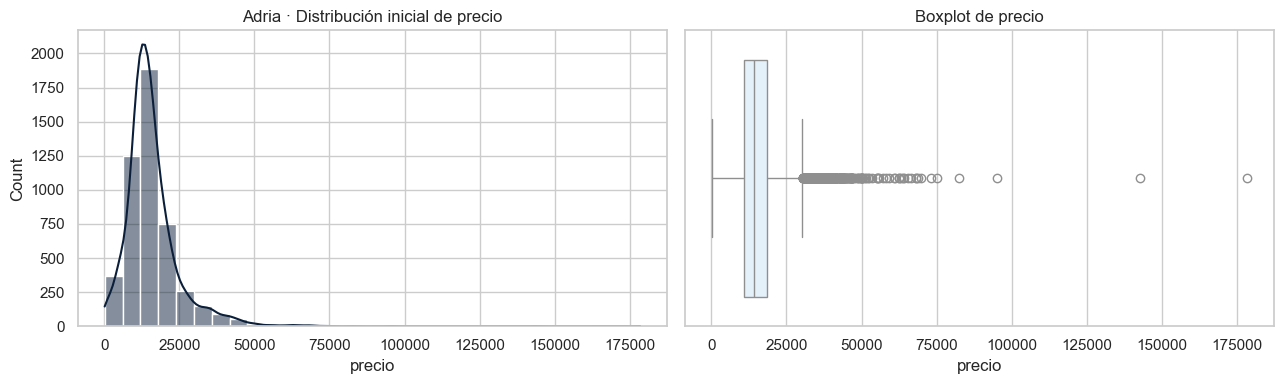

In [72]:
plot_distribution(df_adria, "precio", "Adria · Distribución inicial de precio")


### Adria · 1.1 Diccionario de variables

Completar o ajustar si se detectan interpretaciones distintas de las variables.


In [73]:
data_dictionary_adria = data_dictionary_base.copy()
pretty_table(data_dictionary_adria)


,variable,descripcion,tipo_esperado
0,marca,Marca del vehículo,categórica
1,modelo,Modelo del vehículo,categórica
2,km,Kilometraje acumulado,numérica
3,potencia,Potencia del vehículo,numérica
4,fecha_registro,Fecha de registro o matriculación,fecha
5,tipo_gasolina,Tipo de combustible,categórica
6,color,Color del vehículo,categórica
7,tipo_coche,Tipo de carrocería,categórica
8,volante_regulable,Indica si el volante es regulable,booleana
9,aire_acondicionado,Indica si tiene aire acondicionado,booleana


## Adria · 2. Limpieza de datos

Objetivo: aplicar reglas claras de limpieza, dejando un dataset coherente antes del preprocessing.

Decisiones sugeridas a revisar:

1. Eliminar filas sin `precio`, porque es la variable objetivo del futuro modelo.
2. Eliminar duplicados exactos si existieran.
3. Convertir fechas a tipo datetime.
4. Normalizar columnas booleanas que vienen mezcladas como texto/bool/nulos.
5. Revisar columnas con demasiados nulos y decidir si imputar o eliminar.


In [74]:
# Copia para limpieza
clean_adria = df_adria.copy()

# 1) Eliminar registros sin target
rows_before_adria = clean_adria.shape[0]
clean_adria = clean_adria.dropna(subset=["precio"])
print(f"Filas eliminadas por precio nulo: {rows_before_adria - clean_adria.shape[0]}")

# 2) Eliminar duplicados exactos
rows_before_adria = clean_adria.shape[0]
clean_adria = clean_adria.drop_duplicates()
print(f"Filas duplicadas eliminadas: {rows_before_adria - clean_adria.shape[0]}")


Filas eliminadas por precio nulo: 6
Filas duplicadas eliminadas: 0


In [75]:
# 3) Conversión de fechas
for col in ["fecha_registro", "fecha_venta"]:
    clean_adria[col] = pd.to_datetime(clean_adria[col], errors="coerce")

pretty_table(clean_adria[["fecha_registro", "fecha_venta"]].head())


,fecha_registro,fecha_venta
0,2012-02-01 00:00:00,2018-01-01 00:00:00
1,NaT,2018-02-01 00:00:00
2,2012-04-01 00:00:00,2018-02-01 00:00:00
3,NaT,2018-02-01 00:00:00
4,NaT,2018-04-01 00:00:00


In [76]:
# 4) Normalización de variables booleanas
boolean_cols_adria = [
    "volante_regulable",
    "aire_acondicionado",
    "camara_trasera",
    "asientos_traseros_plegables",
    "elevalunas_electrico",
    "bluetooth",
    "gps",
    "alerta_lim_velocidad"
]

def to_boolean_adria(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return value
    value_str = str(value).strip().lower()
    if value_str in ["true", "1", "yes", "y", "si", "sí"]:
        return True
    if value_str in ["false", "0", "no", "n"]:
        return False
    return np.nan

for col in boolean_cols_adria:
    clean_adria[col] = clean_adria[col].apply(to_boolean_adria).astype("boolean")

pretty_table(clean_adria[boolean_cols_adria].head())


,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad
0,True,True,False,,True,,True,
1,True,True,False,,False,True,True,True
2,False,False,False,,True,False,True,False
3,True,True,False,,True,True,True,
4,True,True,False,False,False,True,True,True


### Adria · 2.1 Tratamiento de columnas con alto porcentaje de nulos

Registrar acá el criterio elegido por Adria.

Criterio sugerido:

- Si una columna aporta poca información o tiene un porcentaje de nulos muy elevado, evaluar su eliminación.
- Si la columna puede tener valor predictivo, conservarla e imputarla.


In [77]:
# Estado luego de limpieza básica
quality_after_basic_cleaning_adria = resumen_calidad(clean_adria)
pretty_table(quality_after_basic_cleaning_adria)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
11,asientos_traseros_plegables,boolean,"3,388",70.04,2
4,fecha_registro,datetime64[ns],"2,418",49.99,180
7,tipo_coche,object,"1,458",30.14,8
0,marca,object,970,20.05,1
13,bluetooth,boolean,728,15.05,2
15,alerta_lim_velocidad,boolean,728,15.05,2
9,aire_acondicionado,boolean,485,10.03,2
6,color,object,444,9.18,10
5,tipo_gasolina,object,5,0.10,5
8,volante_regulable,boolean,4,0.08,2


In [78]:
# Revisión de marca
if "marca" in clean_adria.columns:
    display(pretty_table(clean_adria["marca"].value_counts(dropna=False).rename_axis("marca").reset_index(name="cantidad")))

# Decisión sugerida: eliminar marca porque el caso de estudio se centra en BMW
# Adria puede comentar esta línea si prefiere conservarla y justificarlo.
if "marca" in clean_adria.columns:
    clean_adria = clean_adria.drop(columns=["marca"])

print("Columnas después del tratamiento de marca:")
print(clean_adria.columns.tolist())


,marca,cantidad
0,BMW,"3,867"
1,nan,970


Columnas después del tratamiento de marca:
['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta']


### Adria · 2.2 Imputación de valores faltantes

Registrar acá las decisiones de imputación.

Criterio sugerido:

- Numéricas: mediana.
- Categóricas: `desconocido`.
- Booleanas: `False` como supuesto de característica no informada/no presente.
- Fechas: crear variables temporales y luego imputar las variables derivadas.


In [79]:
# Imputación de categóricas simples
categorical_cols_adria = ["modelo", "tipo_gasolina", "color", "tipo_coche"]
for col in categorical_cols_adria:
    if col in clean_adria.columns:
        clean_adria[col] = clean_adria[col].fillna("desconocido").astype(str).str.strip().str.lower()

# Imputación de booleanas
for col in boolean_cols_adria:
    if col in clean_adria.columns:
        clean_adria[col] = clean_adria[col].fillna(False).astype(bool)

# Imputación de numéricas base
numeric_base_cols_adria = ["km", "potencia"]
for col in numeric_base_cols_adria:
    clean_adria[col] = clean_adria[col].fillna(clean_adria[col].median())

pretty_table(resumen_calidad(clean_adria))


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
3,fecha_registro,datetime64[ns],"2,418",49.99,180
16,fecha_venta,datetime64[ns],1,0.02,13
1,km,float64,0,0.00,"4,778"
15,precio,float64,0,0.00,437
0,modelo,object,0,0.00,77
2,potencia,float64,0,0.00,61
5,color,object,0,0.00,11
6,tipo_coche,object,0,0.00,9
4,tipo_gasolina,object,0,0.00,5
7,volante_regulable,bool,0,0.00,2


### Adria · 2.3 Tratamiento de outliers

Para este entregable, el tratamiento debe ser conservador porque todavía no se modela.

Propuesta base: winsorización por IQR en `precio`, `km` y `potencia`.


In [80]:
def winsorize_iqr_adria(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower=lower, upper=upper), lower, upper

outlier_limits_adria = []
for col in ["precio", "km", "potencia"]:
    clean_adria[col], lower, upper = winsorize_iqr_adria(clean_adria[col])
    outlier_limits_adria.append({"variable": col, "limite_inferior": lower, "limite_superior": upper})

outlier_limits_adria = pd.DataFrame(outlier_limits_adria)
pretty_table(outlier_limits_adria)


,variable,limite_inferior,limite_superior
0,precio,-900.00,"30,300.00"
1,km,"-5,642.50","283,761.50"
2,potencia,47.50,187.50


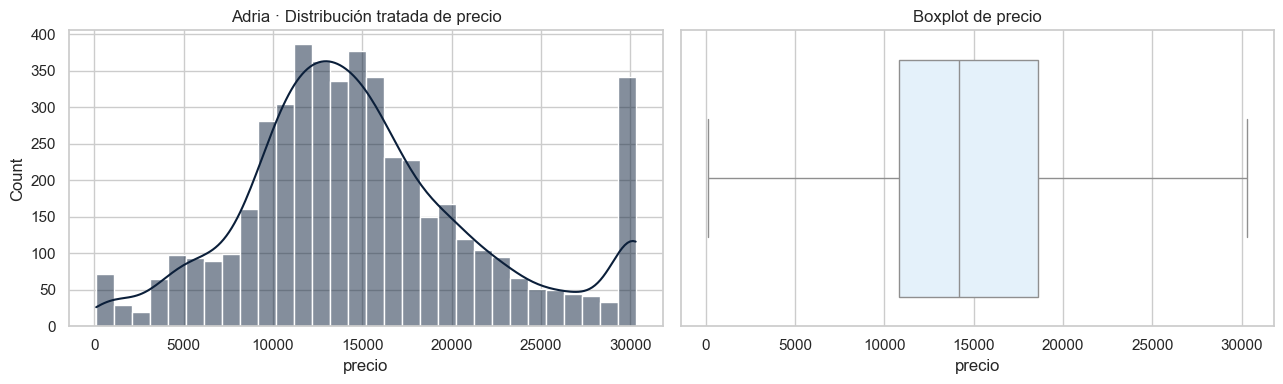

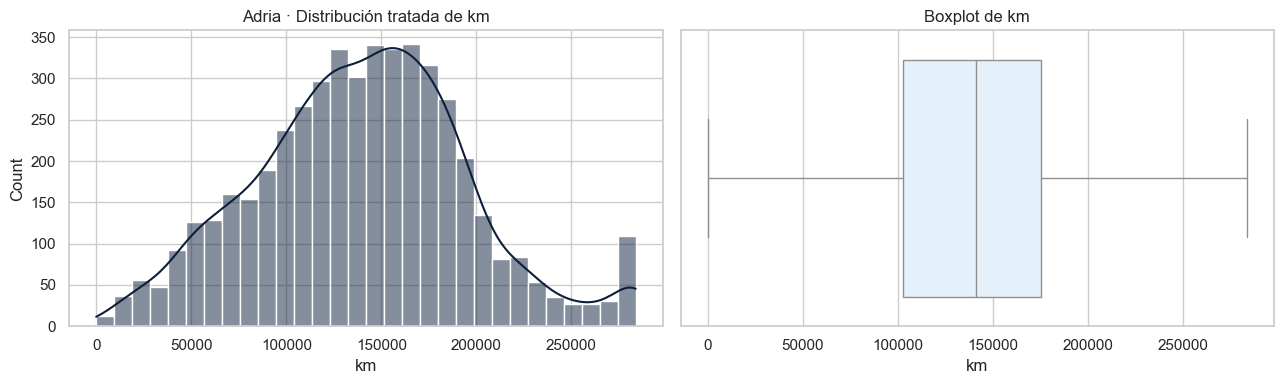

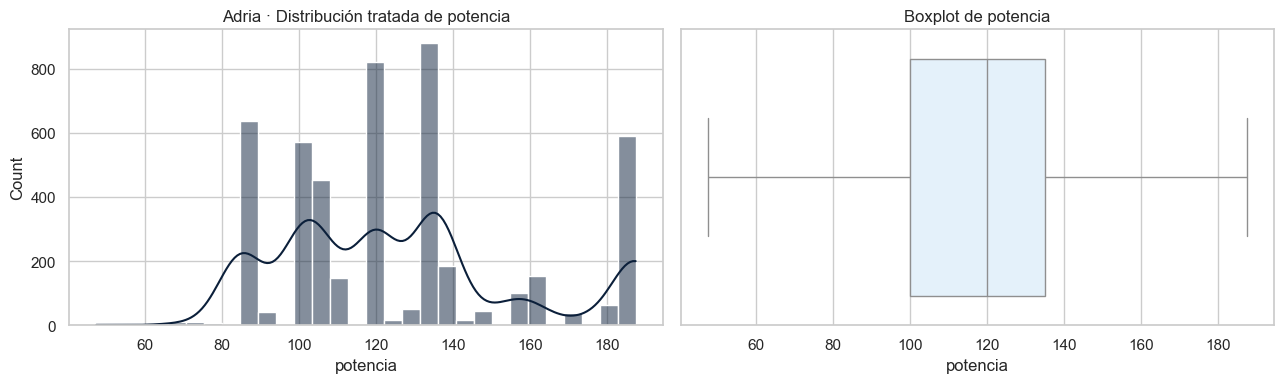

In [81]:
for col in ["precio", "km", "potencia"]:
    plot_distribution(clean_adria, col, f"Adria · Distribución tratada de {col}")


## Adria · 3. Feature engineering

Objetivo: crear variables útiles para modelado sin entrenar ningún modelo.

Variables derivadas propuestas:

- `antiguedad_meses`: diferencia entre fecha de venta y fecha de registro.
- `anio_registro` y `mes_registro`.
- `anio_venta` y `mes_venta`.
- `precio_log`: transformación logarítmica de la variable objetivo para análisis futuro.
- `n_equipamiento`: cantidad de características booleanas presentes.


In [82]:
features_adria = clean_adria.copy()

# Variables temporales
features_adria["anio_registro"] = features_adria["fecha_registro"].dt.year
features_adria["mes_registro"] = features_adria["fecha_registro"].dt.month
features_adria["anio_venta"] = features_adria["fecha_venta"].dt.year
features_adria["mes_venta"] = features_adria["fecha_venta"].dt.month

# Antigüedad en meses
features_adria["antiguedad_meses"] = (
    (features_adria["fecha_venta"].dt.year - features_adria["fecha_registro"].dt.year) * 12 +
    (features_adria["fecha_venta"].dt.month - features_adria["fecha_registro"].dt.month)
)

# Si por nulos o errores queda antigüedad negativa, se reemplaza por NaN antes de imputar
features_adria.loc[features_adria["antiguedad_meses"] < 0, "antiguedad_meses"] = np.nan

# Imputación de variables temporales derivadas
for col in ["anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses"]:
    features_adria[col] = features_adria[col].fillna(features_adria[col].median())

# Transformación de target para análisis futuro
features_adria["precio_log"] = np.log1p(features_adria["precio"])

# Conteo de equipamiento
features_adria["n_equipamiento"] = features_adria[boolean_cols_adria].sum(axis=1)

pretty_table(features_adria.head())


,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento
0,118,"140,411.00",100.00,2012-02-01 00:00:00,diesel,black,desconocido,True,True,False,False,True,False,True,False,"11,300.00",2018-01-01 00:00:00,"2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4
1,m4,"13,929.00",187.50,NaT,petrol,grey,convertible,True,True,False,False,False,True,True,True,"30,300.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5
2,320,"183,297.00",120.00,2012-04-01 00:00:00,diesel,white,desconocido,False,False,False,False,True,False,True,False,"10,200.00",2018-02-01 00:00:00,"2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2
3,420,"128,035.00",135.00,NaT,diesel,red,convertible,True,True,False,False,True,True,True,False,"25,100.00",2018-02-01 00:00:00,"2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5
4,425,"97,097.00",160.00,NaT,diesel,silver,desconocido,True,True,False,False,False,True,True,True,"30,300.00",2018-04-01 00:00:00,"2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5


In [83]:
# Revisión de correlaciones numéricas con precio
numeric_for_corr_adria = ["precio", "precio_log", "km", "potencia", "antiguedad_meses", "n_equipamiento"]
corr_adria = features_adria[numeric_for_corr_adria].corr(numeric_only=True)
pretty_table(corr_adria)


,precio,precio_log,km,potencia,antiguedad_meses,n_equipamiento
precio,1.00,0.86,-0.44,0.65,-0.35,0.53
precio_log,0.86,1.00,-0.41,0.48,-0.42,0.46
km,-0.44,-0.41,1.00,-0.03,0.33,0.05
potencia,0.65,0.48,-0.03,1.00,-0.06,0.54
antiguedad_meses,-0.35,-0.42,0.33,-0.06,1.00,-0.07
n_equipamiento,0.53,0.46,0.05,0.54,-0.07,1.00


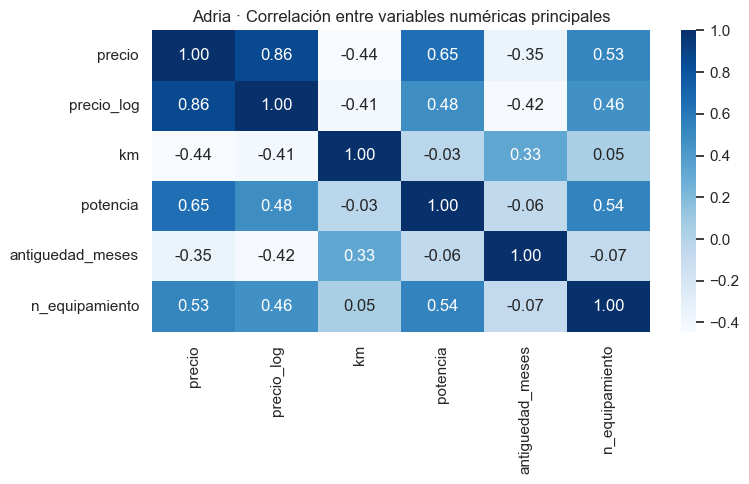

In [84]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_adria, annot=True, fmt=".2f", cmap="Blues")
plt.title("Adria · Correlación entre variables numéricas principales")
plt.tight_layout()
plt.show()


## Adria · 4. Preprocessing para modelado posterior

Objetivo: dejar preparado un dataset numérico que pueda entrar en un modelo en el próximo entregable.

Decisiones sugeridas:

- Eliminar fechas originales porque ya fueron transformadas en variables numéricas.
- Variables categóricas: one-hot encoding.
- Variables booleanas: conversión a 0/1.
- Variables numéricas: escalado estándar para variables continuas.
- Mantener `precio` como target y sacar `precio_log` de las predictoras para evitar fuga de información.


In [85]:
model_ready_adria = features_adria.copy()

# Fechas originales fuera del dataset final de modelado
model_ready_adria = model_ready_adria.drop(columns=["fecha_registro", "fecha_venta"])

# Booleanas a 0/1
for col in boolean_cols_adria:
    if col in model_ready_adria.columns:
        model_ready_adria[col] = model_ready_adria[col].astype(int)

# Categóricas a one-hot
categorical_cols_model_adria = [col for col in ["modelo", "tipo_gasolina", "color", "tipo_coche"] if col in model_ready_adria.columns]
model_ready_adria = pd.get_dummies(model_ready_adria, columns=categorical_cols_model_adria, drop_first=True, dtype=int)

print("Dimensión después de encoding:", model_ready_adria.shape)
pretty_table(model_ready_adria.head())


Dimensión después de encoding: (4837, 116)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,precio_log,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van
0,"140,411.00",100.00,1,1,0,0,1,0,1,0,"11,300.00","2,012.00",2.00,"2,018.00",1.00,71.00,9.33,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,"13,929.00",187.50,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,"183,297.00",120.00,0,0,0,0,1,0,1,0,"10,200.00","2,012.00",4.00,"2,018.00",2.00,70.00,9.23,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,"128,035.00",135.00,1,1,0,0,1,1,1,0,"25,100.00","2,013.00",6.00,"2,018.00",2.00,58.00,10.13,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,"97,097.00",160.00,1,1,0,0,0,1,1,1,"30,300.00","2,013.00",6.00,"2,018.00",4.00,58.00,10.32,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [86]:
# Separación conceptual de features y target, sin entrenar modelo
TARGET_ADRIA = "precio"

y_adria = model_ready_adria[TARGET_ADRIA].copy()
X_adria = model_ready_adria.drop(columns=[TARGET_ADRIA])

# Dejamos precio_log fuera de X para evitar fuga de información respecto al target precio
if "precio_log" in X_adria.columns:
    X_adria = X_adria.drop(columns=["precio_log"])

# Escalado de numéricas continuas
continuous_cols_adria = ["km", "potencia", "anio_registro", "mes_registro", "anio_venta", "mes_venta", "antiguedad_meses", "n_equipamiento"]
continuous_cols_adria = [col for col in continuous_cols_adria if col in X_adria.columns]

scaler_adria = StandardScaler()
X_scaled_adria = X_adria.copy()
X_scaled_adria[continuous_cols_adria] = scaler_adria.fit_transform(X_scaled_adria[continuous_cols_adria])

# Dataset final preparado con target al final
prepared_adria = pd.concat([X_scaled_adria, y_adria], axis=1)

print("X preparada:", X_scaled_adria.shape)
print("Target:", y_adria.shape)
print("Dataset final preparado:", prepared_adria.shape)
pretty_table(prepared_adria.head())


X preparada: (4837, 114)
Target: (4837,)
Dataset final preparado: (4837, 115)


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,anio_registro,mes_registro,anio_venta,mes_venta,antiguedad_meses,n_equipamiento,modelo_116,modelo_118,modelo_120,modelo_123,modelo_125,modelo_135,modelo_214 gran tourer,modelo_216,modelo_216 active tourer,modelo_216 gran tourer,modelo_218,modelo_218 active tourer,modelo_218 gran tourer,modelo_220,modelo_220 active tourer,modelo_225,modelo_225 active tourer,modelo_316,modelo_318,modelo_318 gran turismo,modelo_320,modelo_320 gran turismo,modelo_325,modelo_325 gran turismo,modelo_328,modelo_330,modelo_330 gran turismo,modelo_335,modelo_335 gran turismo,modelo_418 gran coupé,modelo_420,modelo_420 gran coupé,modelo_425,modelo_430,modelo_430 gran coupé,modelo_435,modelo_435 gran coupé,modelo_518,modelo_520,modelo_520 gran turismo,modelo_523,modelo_525,modelo_528,modelo_530,modelo_530 gran turismo,modelo_535,modelo_535 gran turismo,modelo_630,modelo_635,modelo_640,modelo_640 gran coupé,modelo_650,modelo_730,modelo_735,modelo_740,modelo_750,modelo_active tourer,modelo_activehybrid 5,modelo_desconocido,modelo_i3,modelo_i8,modelo_m135,modelo_m235,modelo_m3,modelo_m4,modelo_m5,modelo_m550,modelo_x1,modelo_x3,modelo_x4,modelo_x5,modelo_x5 m,modelo_x5 m50,modelo_x6,modelo_x6 m,modelo_z4,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_desconocido,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van,precio
0,0.01,-0.83,1,1,0,0,1,0,1,0,-0.42,-1.71,0.03,-1.82,0.45,0.24,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,"11,300.00"
1,-2.26,1.96,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"30,300.00"
2,0.78,-0.19,0,0,0,0,1,0,1,0,-0.42,-0.87,0.03,-1.36,0.40,-0.93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,"10,200.00"
3,-0.21,0.28,1,1,0,0,1,1,1,0,0.14,-0.02,0.03,-1.36,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,"25,100.00"
4,-0.77,1.08,1,1,0,0,0,1,1,1,0.14,-0.02,0.03,-0.43,-0.16,0.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,"30,300.00"


## Adria · 5. Validaciones finales y exportación

Objetivo: comprobar que el dataset final cumple con el entregable.

Validaciones:

- No hay nulos.
- No hay duplicados exactos.
- Todas las columnas predictoras son numéricas.
- La variable objetivo está presente.
- Se exporta el dataset limpio/preparado de este bloque.


In [87]:
validation_report_adria = pd.DataFrame({
    "validacion": [
        "Dataset final sin nulos",
        "Dataset final sin duplicados exactos",
        "Variable objetivo presente",
        "Predictoras numéricas",
        "Filas disponibles para modelado",
        "Columnas disponibles para modelado"
    ],
    "resultado": [
        prepared_adria.isna().sum().sum() == 0,
        prepared_adria.duplicated().sum() == 0,
        TARGET_ADRIA in prepared_adria.columns,
        all(pd.api.types.is_numeric_dtype(prepared_adria[col]) for col in prepared_adria.drop(columns=[TARGET_ADRIA]).columns),
        prepared_adria.shape[0],
        prepared_adria.shape[1]
    ]
})

pretty_table(validation_report_adria)


,validacion,resultado
0,Dataset final sin nulos,True
1,Dataset final sin duplicados exactos,True
2,Variable objetivo presente,True
3,Predictoras numéricas,True
4,Filas disponibles para modelado,"4,837"
5,Columnas disponibles para modelado,115


In [88]:
# Exportación de datasets del bloque de Adria
features_adria.to_csv("bmw_pricing_clean_features_adria.csv", index=False)
prepared_adria.to_csv("bmw_pricing_prepared_model_ready_adria.csv", index=False)

print("Archivos exportados:")
print("- bmw_pricing_clean_features_adria.csv")
print("- bmw_pricing_prepared_model_ready_adria.csv")


Archivos exportados:
- bmw_pricing_clean_features_adria.csv
- bmw_pricing_prepared_model_ready_adria.csv


## Adria · 6. Conclusiones del bloque

Completar al finalizar el trabajo:

- Principales problemas detectados en el dataset.
- Decisiones de limpieza tomadas.
- Estrategia de imputación utilizada.
- Tratamiento de outliers aplicado.
- Variables creadas.
- Limitaciones o supuestos del enfoque.
- Recomendación para la versión final del equipo.


# Comparación y consolidación final del equipo

Una vez que cada integrante complete su bloque, usar esta sección para comparar enfoques y decidir una versión final común.

Criterios sugeridos para elegir la versión final:

- Menor cantidad de supuestos débiles.
- Mayor trazabilidad de decisiones.
- Dataset final sin nulos ni duplicados.
- Variables interpretables y útiles para modelado futuro.
- Código reproducible de principio a fin.


In [89]:
# Comparación rápida de las salidas generadas por cada integrante
comparacion_equipo = []

for integrante, prepared_name in [
    ("Juan", "prepared_juan"),
    ("Maxi", "prepared_maxi"),
    ("Carmen", "prepared_carmen"),
    ("Adria", "prepared_adria"),
]:
    if prepared_name in globals():
        dataset = globals()[prepared_name]
        comparacion_equipo.append({
            "integrante": integrante,
            "filas": dataset.shape[0],
            "columnas": dataset.shape[1],
            "nulos": int(dataset.isna().sum().sum()),
            "duplicados": int(dataset.duplicated().sum())
        })

comparacion_equipo = pd.DataFrame(comparacion_equipo)
pretty_table(comparacion_equipo)


,integrante,filas,columnas,nulos,duplicados
0,Juan,"4,837",115,0,0
1,Maxi,"4,837",115,0,0
2,Carmen,"4,837",115,0,0
3,Adria,"4,837",115,0,0
